In [26]:
# Ignore warning messages
import warnings
warnings.filterwarnings('ignore')

# Data handling libraries
import pandas as pd      # For data manipulation
import numpy as np       # For numerical operations

# Visualization libraries
import matplotlib
matplotlib.use('Agg')    # Use non-GUI backend (for saving plots)

import matplotlib.pyplot as plt      # Plotting graphs
import matplotlib.gridspec as gridspec  # Advanced subplot layouts
import seaborn as sns                # Statistical visualizations

# Utility libraries
from collections import Counter  # Count frequency of elements
import itertools                 # Combinatorial tools
import os                        # File system operations

# Preprocessing tools
from sklearn.preprocessing import StandardScaler, LabelEncoder
# StandardScaler → normalize data
# LabelEncoder → convert categorical data to numeric

# Clustering algorithm
from sklearn.cluster import KMeans  # KMeans clustering

# Dimensionality reduction
from sklearn.decomposition import PCA  # Reduce number of features

# Evaluation metric
from sklearn.metrics import silhouette_score  # Measure clustering quality

This code imports essential libraries for data analysis, visualization, and machine learning.
It includes tools for handling data (pandas, numpy), plotting (matplotlib, seaborn), preprocessing (StandardScaler, LabelEncoder), clustering (KMeans), dimensionality reduction (PCA), and evaluation (silhouette_score).
Warnings are suppressed and a non-GUI backend is set for plotting.

In [27]:
# -------------------------------
# Aesthetic configuration for plots
# -------------------------------

# Custom color palette (Zomato-inspired colors)
PALETTE = [
    '#E23744',  # Red
    '#FC8019',  # Orange
    '#FFB347',  # Light Orange
    '#2ECC71',  # Green
    '#3498DB',  # Blue
    '#9B59B6',  # Purple
    '#1ABC9C',  # Teal
    '#E74C3C'   # Dark Red
]

# Define primary theme colors
ZOMATO_RED = '#E23744'
ZOMATO_ORG = '#FC8019'
BG_COLOR   = '#FAFAFA'  # Light background color

# Apply Seaborn theme
sns.set_theme(
    style='whitegrid',   # Grid style background
    palette=PALETTE      # Use custom color palette
)

# Update Matplotlib default settings
plt.rcParams.update({
    'figure.dpi': 130,          # Resolution of figures
    'axes.titlesize': 13,       # Title font size
    'axes.labelsize': 11,       # Axis label size
    'xtick.labelsize': 9,       # X-axis tick size
    'ytick.labelsize': 9,       # Y-axis tick size
    'font.family': 'DejaVu Sans',  # Font style
    'axes.spines.top': False,   # Remove top border
    'axes.spines.right': False  # Remove right border
})

This code sets up the visual styling for plots.
It defines a custom color palette (inspired by Zomato), sets a background color, and configures Seaborn and Matplotlib settings like font size, DPI, and plot aesthetics for cleaner and consistent visualizations.

In [28]:
# -------------------------------
# Create output directory
# -------------------------------

# Path where all output images will be saved
OUTPUT_DIR = "D:\\Data Analytics\\Project 2\\Output"

# Create directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)


# -------------------------------
# Function to save plots
# -------------------------------

def savefig(name, fig=None, tight=True):
    """
    Saves a matplotlib figure to the output directory.

    Parameters:
    name  : filename of the image
    fig   : specific figure object (optional)
    tight : whether to apply tight layout
    """

    # Full path for saving the file
    path = f"{OUTPUT_DIR}/{name}"

    # Adjust layout to avoid overlap
    if tight:
        plt.tight_layout()

    # Save the figure
    if fig:
        fig.savefig(path, bbox_inches='tight', facecolor=BG_COLOR)
    else:
        plt.savefig(path, bbox_inches='tight', facecolor=BG_COLOR)

    # Close the plot to free memory
    plt.close()

    # Confirmation message
    print(f"  ✔ saved → {path}")

This code creates an output directory to store plots and defines a helper function savefig() to save figures automatically with proper layout and background. It ensures all plots are saved consistently and closes them after saving.

In [29]:
# -------------------------------
# Day of Week Mapping
# -------------------------------

# Map numerical day index to day name
# (Typically used when days are encoded as numbers)
DOW_MAP = {
    0: 'Mon',
    1: 'Tue',
    2: 'Wed',
    3: 'Thu',
    4: 'Fri',
    5: 'Sat',
    6: 'Sun'
}

# Standard order of days (useful for sorting plots or tables)
DAY_ORDER = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

This code defines mappings for days of the week.
DOW_MAP converts numeric day values (0–6) into day names, while DAY_ORDER ensures a consistent order for plotting or analysis.

In [30]:
# -------------------------------
# Load dataset
# -------------------------------

# File path of the dataset
DATA_PATH = r"D:\Data Analytics\Project 2\csao_session_dataset\csao_session_dataset.csv"

# Read CSV file into a pandas DataFrame
df_raw = pd.read_csv(DATA_PATH)

# Display dataset dimensions (rows, columns)
print("Dataset Shape:", df_raw.shape)

# Show first 5 rows of the dataset
df_raw.head()

Dataset Shape: (100000, 57)


,session_id,session_timestamp,user_id,restaurant_id,restaurant_name,user_segment,user_city,user_preferred_cuisine,user_veg_preference,user_price_sensitivity,...,actual_added_addon_names,actual_added_addon_categories,actual_added_addon_count,actual_added_addon_value,any_addon_added,final_order_value,avg_reco_score,avg_reco_price_ratio,avg_reco_popularity,avg_reco_is_complementary
0,0,2025-01-01 00:00:00,2342,428,Great Wall Restaurant - Branch 3,mid,mumbai,chinese,0,0.797196,...,none,none,0,0.0,0,253.43,0.3661,0.3751,0.6733,0.500
1,1,2025-01-01 00:05:00,1564,52,SodaBottleOpenerWala,mid,hyderabad,chinese,1,0.496768,...,none,none,0,0.0,0,158.14,0.4492,0.3872,0.4496,1.000
2,2,2025-01-01 00:10:00,3159,386,SLV Corner - Branch 4,mid,chennai,south_indian,0,0.392278,...,none,none,0,0.0,0,175.46,0.4260,0.4457,0.5701,0.750
3,3,2025-01-01 00:15:00,1022,95,The Bigg Small Cafe - Branch 2,budget,bengaluru,north_indian,0,0.623821,...,none,none,0,0.0,0,170.42,0.4789,0.3331,0.4494,1.000
4,4,2025-01-01 00:20:00,3883,393,Nandhini Restaurant - Branch 4,premium,hyderabad,south_indian,1,0.522527,...,none,none,0,0.0,0,220.40,0.5762,0.2803,0.5543,0.875


This code loads a dataset from a CSV file into a DataFrame, then displays its shape (rows, columns) and a preview of the first few rows.

In [31]:
# -------------------------------
# Column descriptions dictionary
# -------------------------------

# Map each column name to its description
col_desc = {
    # Identifiers & timestamp
    'session_id': 'Unique session identifier',
    'session_timestamp': 'Datetime when session started',
    'user_id': 'Anonymised user ID',
    'restaurant_id': 'Anonymised restaurant ID',
    'restaurant_name': 'Restaurant display name',

    # User attributes
    'user_segment': 'CRM user segment (e.g. Gold, Silver)',
    'user_city': 'City of the user',
    'user_veg_preference': '1 = prefers vegetarian food',
    'user_price_sensitivity': 'Price sensitivity score (0–1)',
    'user_order_frequency_30d': 'Orders in last 30 days',
    'user_avg_order_value': 'Average order value (₹)',
    'user_recency_days': 'Days since last order',
    'num_past_orders_at_restaurant': 'Past orders at this restaurant',
    'user_addon_acceptance_rate': 'Past add-on acceptance rate',
    'user_preferred_addon_category': 'Most accepted add-on category',

    # Restaurant attributes
    'restaurant_city': 'City of restaurant',
    'restaurant_cuisine': 'Cuisine type',
    'restaurant_type': 'Type (Casual, Fine Dining, etc.)',
    'restaurant_online_order': 'Online ordering available (Yes/No)',
    'restaurant_price_tier': 'Price level (1–4)',
    'restaurant_rating': 'Rating (0–5)',
    'restaurant_is_chain': '1 = chain, 0 = standalone',
    'restaurant_delivery_time_avg': 'Avg delivery time (min)',
    'restaurant_avg_orders_per_day': 'Daily order volume',

    # Context
    'hour': 'Hour of day (0–23)',
    'day_of_week': 'Day (0=Mon to 6=Sun)',
    'meal_time': 'Meal type',
    'is_weekend': '1 = weekend',
    'has_offer': '1 = discount available',
    'weather_condition': 'Weather type',
    'traffic_density': 'Traffic level',
    'is_festival_day': '1 = festival',
    'estimated_delivery_time': 'Estimated delivery time',
    'delivery_zone': 'Zone ID',

    # Cart details
    'session_engagement_score': 'User engagement score',
    'base_cart_item_names': 'Items in cart',
    'base_cart_item_categories': 'Item categories',
    'base_cart_item_count': 'Number of items',
    'base_cart_value': 'Cart value (₹)',
    'cart_has_drink': '1 = drink present',
    'cart_has_dessert': '1 = dessert present',
    'cart_has_side': '1 = side present',
    'cart_completion_score': 'Meal completeness score',

    # Recommendations
    'recommended_addon_names': 'Suggested add-ons',
    'recommended_addon_categories': 'Suggested categories',
    'recommended_addon_prices': 'Suggested prices',
    'actual_added_addon_names': 'Added add-ons',
    'actual_added_addon_categories': 'Added categories',
    'actual_added_addon_count': 'Number of add-ons added',
    'actual_added_addon_value': 'Revenue from add-ons',

    # Outcome
    'any_addon_added': '1 = at least one add-on added',
    'final_order_value': 'Total order value',
    'avg_reco_score': 'Average recommendation score',
    'avg_reco_price_ratio': 'Price ratio',
    'avg_reco_popularity': 'Popularity score',
    'avg_reco_is_complementary': 'Complementary fraction'
}

# -------------------------------
# Print column descriptions
# -------------------------------

# Loop through dictionary and print each column with its description
for col, desc in col_desc.items():
    print(f"  {col:<35} → {desc}")

  session_id                          → Unique session identifier
  session_timestamp                   → Datetime when session started
  user_id                             → Anonymised user ID
  restaurant_id                       → Anonymised restaurant ID
  restaurant_name                     → Restaurant display name
  user_segment                        → CRM user segment (e.g. Gold, Silver)
  user_city                           → City of the user
  user_veg_preference                 → 1 = prefers vegetarian food
  user_price_sensitivity              → Price sensitivity score (0–1)
  user_order_frequency_30d            → Orders in last 30 days
  user_avg_order_value                → Average order value (₹)
  user_recency_days                   → Days since last order
  num_past_orders_at_restaurant       → Past orders at this restaurant
  user_addon_acceptance_rate          → Past add-on acceptance rate
  user_preferred_addon_category       → Most accepted add-on category
  rest

This code creates a dictionary col_desc that maps each dataset column to its description.
It then iterates through the dictionary and prints each column name along with its meaning for better understanding of the data

In [32]:
# -------------------------------
# Create a working copy of dataset
# -------------------------------

# Copy the original DataFrame to avoid modifying it directly
df = df_raw.copy()

This code creates a copy of the original dataset so that any modifications can be done safely without changing the original data.

In [33]:
# -------------------------------
# Convert session_timestamp to datetime
# -------------------------------

# Convert column to datetime; invalid parsing becomes NaT
df['session_timestamp'] = pd.to_datetime(
    df['session_timestamp'],
    errors='coerce'
)

# Print confirmation
print("session_timestamp parsed")

# Count and display number of null datetime values
print("Null datetimes:", df['session_timestamp'].isna().sum())

session_timestamp parsed
Null datetimes: 0


This code converts the session_timestamp column to datetime format. Invalid values are turned into NaT (null), and then the number of missing timestamps is printed.

In [34]:
# -------------------------------
# Missing values analysis
# -------------------------------

# Count missing values in each column
missing = df.isnull().sum()

# Calculate percentage of missing values
missing_pct = (missing / len(df) * 100).round(2)

# Create a report DataFrame
mv_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

# Filter columns that actually have missing values
has_missing = mv_report[mv_report['Missing Count'] > 0]

# Display result
if len(has_missing):
    display(has_missing)  # Show only columns with missing values
else:
    print("✔ No missing values detected")  # If no missing values

✔ No missing values detected


This code checks for missing values in the dataset, calculates their count and percentage, and displays only the columns that contain missing data.

In [35]:
# -------------------------------
# Handle duplicate session IDs
# -------------------------------

# Count duplicate session_id entries
dupes = df.duplicated(subset='session_id').sum()
print("Duplicate session_ids:", dupes)

# Remove duplicates, keeping the first occurrence
df.drop_duplicates(subset='session_id', keep='first', inplace=True)

# Reset index after dropping rows
df.reset_index(drop=True, inplace=True)

# Print updated dataset shape
print("Cleaned dataset shape:", df.shape)

Duplicate session_ids: 0
Cleaned dataset shape: (100000, 57)


This code checks for duplicate session IDs, removes duplicates while keeping the first occurrence, and resets the index to maintain a clean dataset.

In [36]:
# -------------------------------
# Convert day_of_week to day names
# -------------------------------

# Map numeric day values (0–6) to corresponding day names
df['day_name'] = df['day_of_week'].map(DOW_MAP)

This code creates a new column day_name by converting numeric day values into day labels (Mon–Sun) using the predefined mapping.

In [37]:
# -------------------------------
# Outlier Detection using IQR
# -------------------------------

print("Outlier Detection (IQR)\n")

# List of columns to check for outliers
cols = [
    'base_cart_value',
    'final_order_value',
    'actual_added_addon_value',
    'session_engagement_score'
]

# Loop through each column
for col in cols:
    
    # Calculate first (Q1) and third quartiles (Q3)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    # Compute Interquartile Range
    IQR = Q3 - Q1
    
    # Count outliers using IQR rule
    n_out = ((df[col] < Q1 - 1.5 * IQR) | 
             (df[col] > Q3 + 1.5 * IQR)).sum()
    
    # Print result
    print(f"{col:<35} → {n_out} outliers (retained — valid business data)")

Outlier Detection (IQR)

base_cart_value                     → 2822 outliers (retained — valid business data)
final_order_value                   → 3187 outliers (retained — valid business data)
actual_added_addon_value            → 23622 outliers (retained — valid business data)
session_engagement_score            → 680 outliers (retained — valid business data)


This code detects outliers using the IQR method for selected numerical columns.
It calculates how many values fall outside the normal range but keeps them since they may be valid business data.

In [38]:
# -------------------------------
# Label Encoding categorical columns
# -------------------------------

from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# List of categorical columns to encode
encode_cols = [
    'user_segment',
    'user_city',
    'user_preferred_cuisine',
    'user_preferred_addon_category',
    'restaurant_cuisine',
    'restaurant_type',
    'meal_time',
    'weather_condition',
    'traffic_density',
    'delivery_zone'
]

# Apply encoding to each column
for col in encode_cols:
    
    # Convert to string (to handle mixed types) and encode
    df[col + "_enc"] = le.fit_transform(df[col].astype(str))

# Print confirmation
print("Label encoding applied ✔")

# Show updated dataset shape
print("Final clean dataset shape:", df.shape)

Label encoding applied ✔
Final clean dataset shape: (100000, 68)


This code applies label encoding to categorical columns, converting them into numeric values so they can be used in machine learning models. New encoded columns are created with _enc suffix.

In [39]:
# -------------------------------
# Setup output directory
# -------------------------------

import os

# Define output folder path
OUTPUT_DIR = r"D:\Data Analytics\Project 2\Output"

# Create directory if it does not exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Confirmation message
print("Output directory ready:", OUTPUT_DIR)

Output directory ready: D:\Data Analytics\Project 2\Output


This code ensures that the output directory exists. If it doesn’t, it creates the folder and confirms it is ready for saving files.

In [40]:
# -------------------------------
# Function to save figure
# -------------------------------

def savefig(filename, fig):
    """
    Save a matplotlib figure to the output directory.
    
    Parameters:
    filename : name of the file to save
    fig      : matplotlib figure object
    """

    # Create full file path
    path = os.path.join(OUTPUT_DIR, filename)
    
    # Save the figure with high resolution
    fig.savefig(
        path,
        dpi=300,                # High-quality image
        bbox_inches='tight'     # Remove extra whitespace
    )
    
    # Print confirmation
    print("Saved:", path)

This code defines a function savefig() to save a given figure to the output directory with high resolution and proper layout.

In [41]:
# -------------------------------
# KPI Dashboard Visualization
# -------------------------------

import matplotlib.pyplot as plt

# -------------------------------
# KPI Calculations
# -------------------------------

# Percentage of sessions where add-on was added
addon_rate = df['any_addon_added'].mean() * 100

# Average values
avg_addon = df['actual_added_addon_value'].mean()
avg_final = df['final_order_value'].mean()
avg_eng = df['session_engagement_score'].mean()
avg_reco = df['avg_reco_score'].mean()

# Average add-on value for users who actually added add-ons
addon_adopters = df[df['any_addon_added'] == 1]['actual_added_addon_value'].mean()


# -------------------------------
# KPI Data (label, value, color)
# -------------------------------

kpis = [
    ("Total Sessions", len(df), "#E23744"),
    ("Unique Users", df['user_id'].nunique(), "#FC8019"),
    ("Add-On Adoption Rate", f"{addon_rate:.1f}%", "#2ECC71"),
    ("Avg Final Order Value", f"₹{avg_final:.0f}", "#3498DB"),
    ("Avg Add-On Value", f"₹{avg_addon:.0f}", "#9B59B6"),
    ("Avg Add-On (Adopters)", f"₹{addon_adopters:.0f}", "#1ABC9C"),
    ("Avg Reco Score", f"{avg_reco:.3f}", "#FFB347"),
    ("Avg Engagement Score", f"{avg_eng:.2f}", "#E74C3C"),
]


# -------------------------------
# Create dashboard layout (2x4 grid)
# -------------------------------

fig, axes = plt.subplots(2, 4, figsize=(18, 7))

# Set overall background color
fig.patch.set_facecolor("#1A1A2E")


# -------------------------------
# Plot each KPI
# -------------------------------

for ax, (label, value, color) in zip(axes.flatten(), kpis):

    # Set card background color
    ax.set_facecolor("#16213E")

    # Display KPI value
    ax.text(
        0.5, 0.6, value,
        ha="center",
        fontsize=22,
        color=color,
        transform=ax.transAxes
    )

    # Display KPI label
    ax.text(
        0.5, 0.3, label,
        ha="center",
        fontsize=10,
        color="white",
        transform=ax.transAxes
    )

    # Remove axis ticks for clean look
    ax.set_xticks([])
    ax.set_yticks([])


# Show dashboard
plt.show()

This code calculates key business KPIs (like add-on rate, average order value, engagement score) and visualizes them in a dashboard-style grid using Matplotlib.

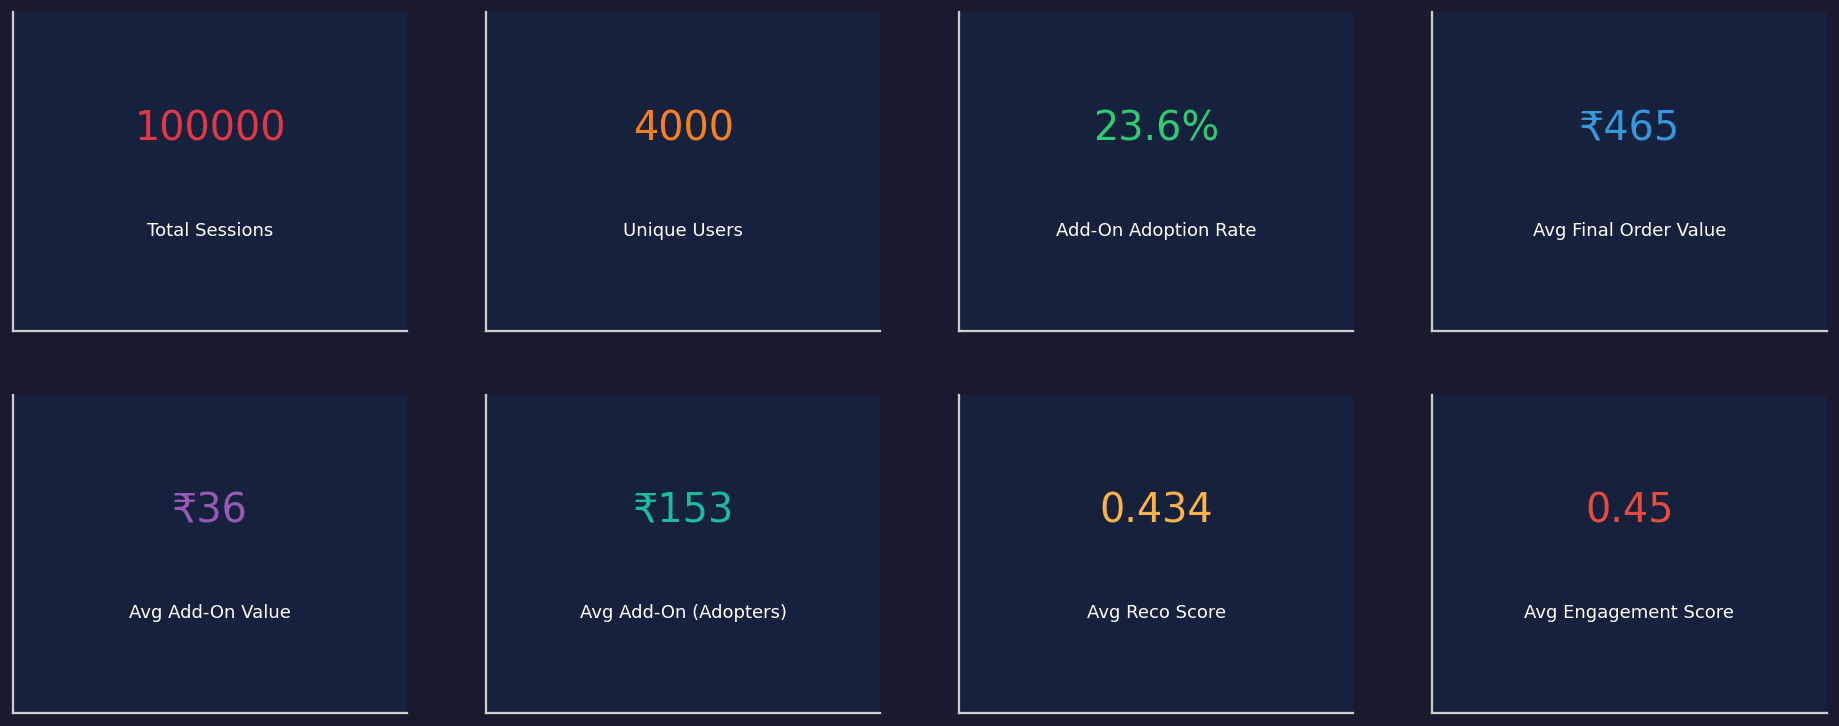

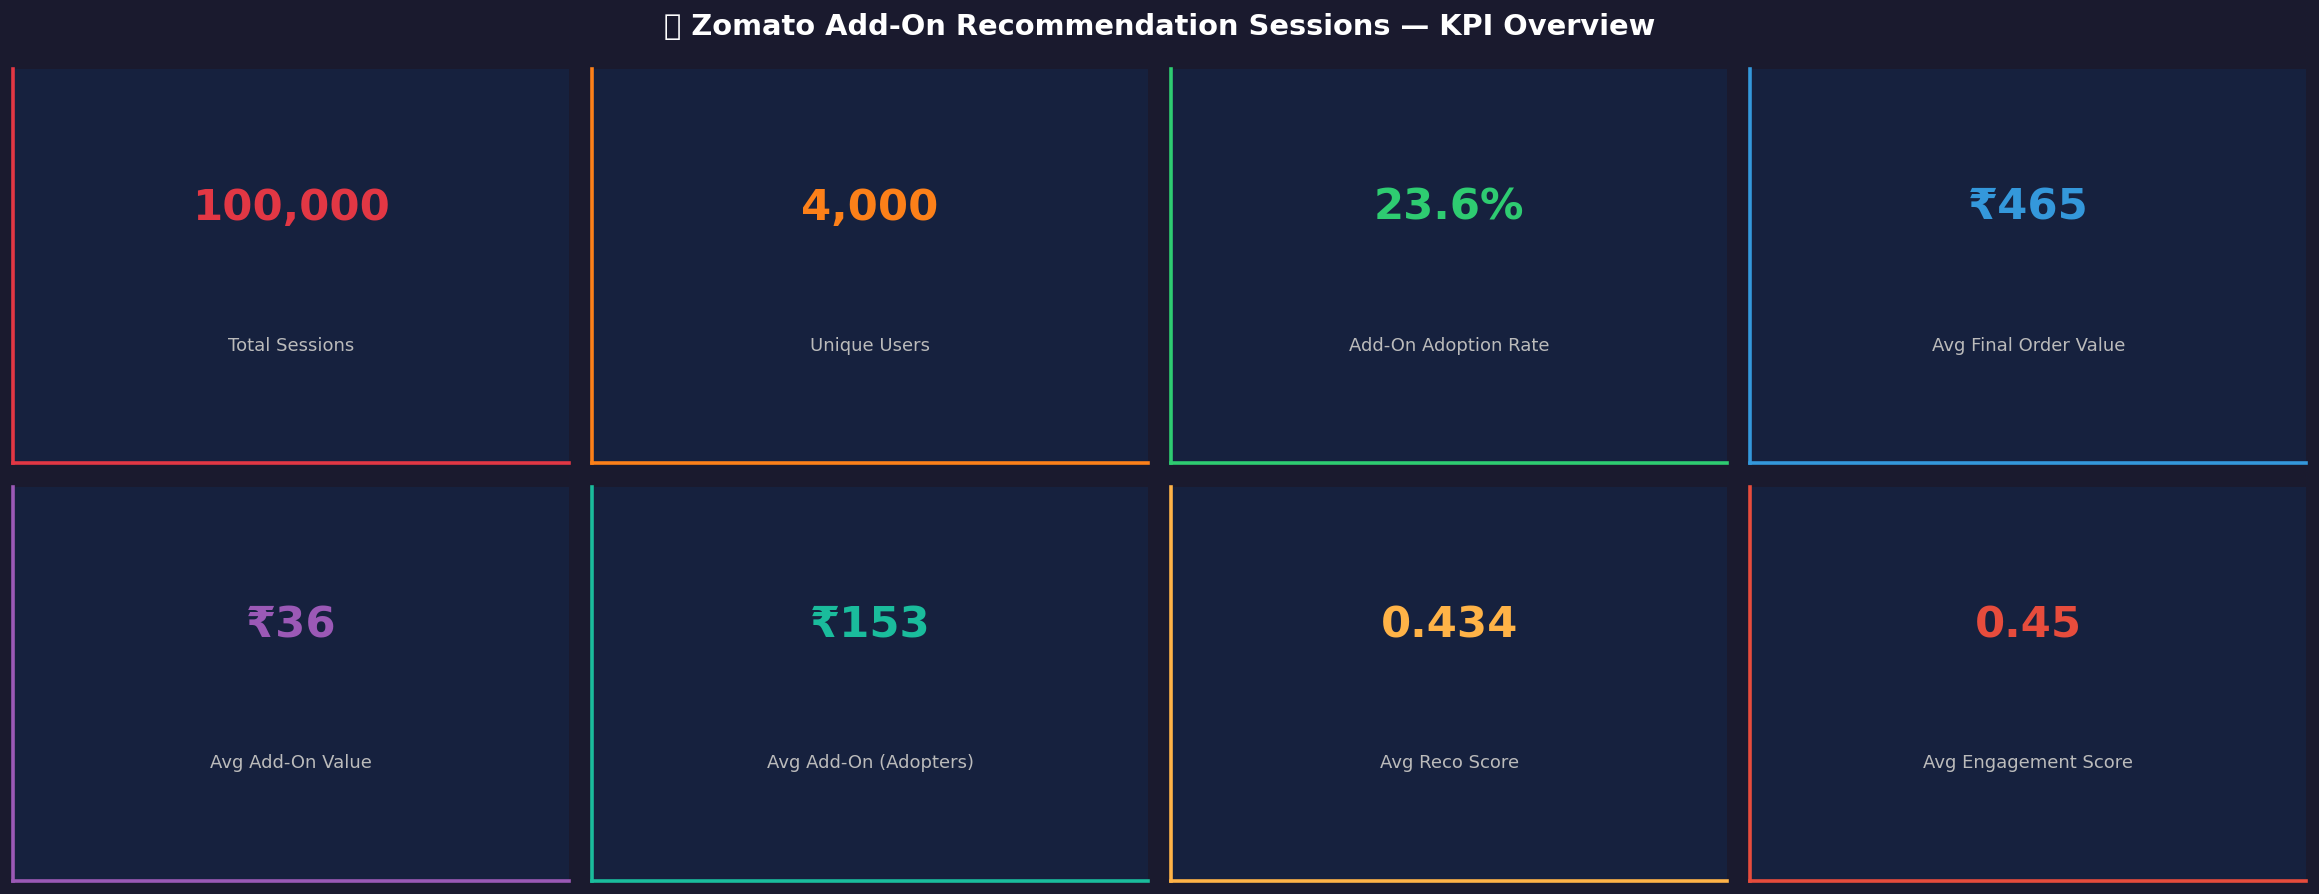

Saved: D:\Data Analytics\Project 2\Output\01_kpi_overview.png


In [43]:
# -------------------------------
# Zomato KPI Dashboard Plot
# -------------------------------

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Enable inline plotting in Jupyter/Colab if available
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except:
    pass


# -------------------------------
# Safety checks for required columns
# -------------------------------

required_cols = [
    'any_addon_added',
    'actual_added_addon_value',
    'final_order_value',
    'session_engagement_score',
    'avg_reco_score',
    'user_id'
]

# Check if any required column is missing
missing = [col for col in required_cols if col not in df.columns]
if missing:
    raise ValueError(f"Missing columns in df: {missing}")


# -------------------------------
# KPI calculations
# -------------------------------

# Percentage of sessions with at least one add-on added
addon_adopt_rate = df['any_addon_added'].mean() * 100

# Average values across all sessions
avg_addon_val = df['actual_added_addon_value'].mean()
avg_final_val = df['final_order_value'].mean()
avg_eng_score = df['session_engagement_score'].mean()
avg_reco_score = df['avg_reco_score'].mean()

# Average add-on value only for sessions where add-on was adopted
addon_val_adopters = df.loc[
    df['any_addon_added'] == 1,
    'actual_added_addon_value'
].mean()

# Replace NaN with 0 in case no adopters exist
addon_val_adopters = 0 if pd.isna(addon_val_adopters) else addon_val_adopters


# -------------------------------
# KPI data for dashboard cards
# -------------------------------

kpis = [
    ('Total Sessions', f"{len(df):,}", '#E23744'),
    ('Unique Users', f"{df['user_id'].nunique():,}", '#FC8019'),
    ('Add-On Adoption Rate', f"{addon_adopt_rate:.1f}%", '#2ECC71'),
    ('Avg Final Order Value', f"₹{avg_final_val:.0f}", '#3498DB'),
    ('Avg Add-On Value', f"₹{avg_addon_val:.0f}", '#9B59B6'),
    ('Avg Add-On (Adopters)', f"₹{addon_val_adopters:.0f}", '#1ABC9C'),
    ('Avg Reco Score', f"{avg_reco_score:.3f}", '#FFB347'),
    ('Avg Engagement Score', f"{avg_eng_score:.2f}", '#E74C3C'),
]


# -------------------------------
# Create dashboard layout
# -------------------------------

fig, axes = plt.subplots(2, 4, figsize=(18, 7))

# Set background color for the full figure
fig.patch.set_facecolor('#1A1A2E')

# Add dashboard title
fig.suptitle(
    '📊 Zomato Add-On Recommendation Sessions — KPI Overview',
    fontsize=16,
    color='white',
    fontweight='bold'
)


# -------------------------------
# Draw KPI cards
# -------------------------------

for ax, (label, value, color) in zip(axes.flatten(), kpis):

    # Set card background
    ax.set_facecolor('#16213E')

    # Add KPI value
    ax.text(
        0.5, 0.65,
        value,
        ha='center',
        va='center',
        fontsize=24,
        fontweight='bold',
        color=color,
        transform=ax.transAxes
    )

    # Add KPI label
    ax.text(
        0.5, 0.30,
        label,
        ha='center',
        va='center',
        fontsize=10,
        color='#BBBBBB',
        transform=ax.transAxes
    )

    # Style card borders
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2)

    # Remove ticks for clean dashboard appearance
    ax.set_xticks([])
    ax.set_yticks([])


# -------------------------------
# Final render
# -------------------------------

plt.tight_layout()
plt.show()
# -------------------------------
# Save the figure
# -------------------------------

savefig('01_kpi_overview.png', fig)

This code creates a more polished KPI dashboard for the dataset.
It first checks whether all required columns exist, calculates important metrics, handles missing values safely, and then displays the KPIs in styled dashboard cards.

Saved: D:\Data Analytics\Project 2\Output\02_user_restaurant_distributions.png


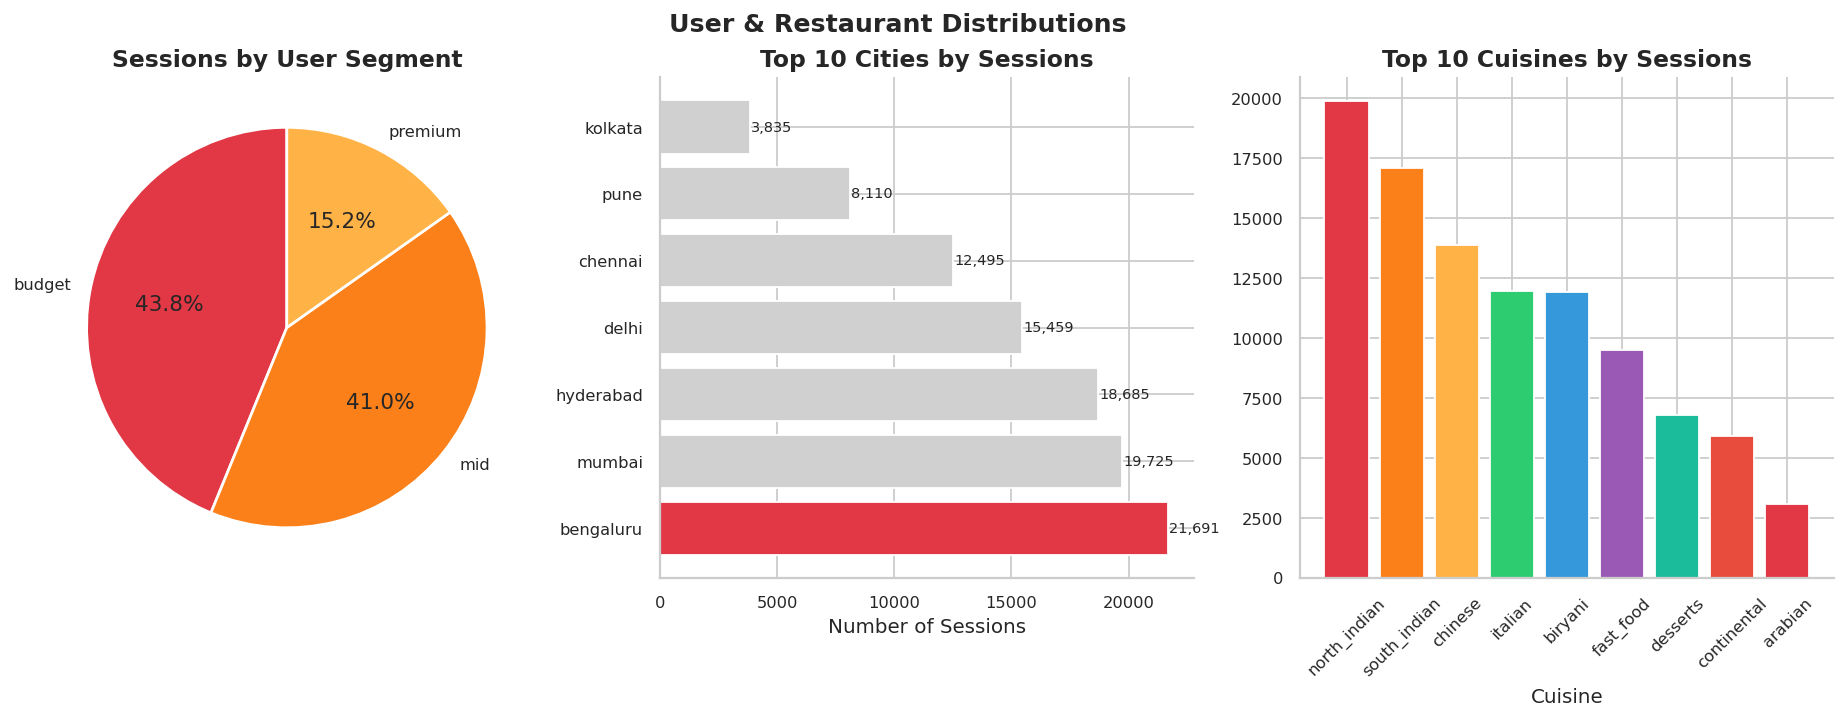

In [44]:
# -------------------------------
# User & Restaurant Distributions
# -------------------------------

# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Add overall title
fig.suptitle('User & Restaurant Distributions', fontsize=14, fontweight='bold')


# -------------------------------
# 1. Pie chart: Sessions by user segment
# -------------------------------

# Count sessions for each user segment
seg_cnt = df['user_segment'].value_counts()

# Plot pie chart
axes[0].pie(
    seg_cnt,
    labels=seg_cnt.index,
    autopct='%1.1f%%',                     # Show percentage
    colors=PALETTE[:len(seg_cnt)],        # Use custom palette
    startangle=90,                        # Start from top
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

# Set subplot title
axes[0].set_title('Sessions by User Segment', fontweight='bold')


# -------------------------------
# 2. Horizontal bar chart: Top 10 cities
# -------------------------------

# Get top 10 cities by session count
city_cnt = df['user_city'].value_counts().head(10)

# Create horizontal bars
bars = axes[1].barh(
    city_cnt.index,
    city_cnt.values,
    color=[ZOMATO_RED if i == 0 else '#D0D0D0' for i in range(len(city_cnt))]
)

# Axis labels and title
axes[1].set_xlabel('Number of Sessions')
axes[1].set_title('Top 10 Cities by Sessions', fontweight='bold')

# Add value labels next to bars
for bar, val in zip(bars, city_cnt.values):
    axes[1].text(
        val + 50,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,}',
        va='center',
        fontsize=8
    )


# -------------------------------
# 3. Vertical bar chart: Top 10 cuisines
# -------------------------------

# Get top 10 cuisines by session count
cuis_cnt = df['restaurant_cuisine'].value_counts().head(10)

# Create bar chart
axes[2].bar(
    cuis_cnt.index,
    cuis_cnt.values,
    color=PALETTE[:len(cuis_cnt)],
    edgecolor='white'
)

# Axis labels and title
axes[2].set_xlabel('Cuisine')
axes[2].set_title('Top 10 Cuisines by Sessions', fontweight='bold')

# Rotate x-axis labels for readability
axes[2].tick_params(axis='x', rotation=45)


# -------------------------------
# Save the figure
# -------------------------------

savefig('02_user_restaurant_distributions.png', fig)

Saved: D:\Data Analytics\Project 2\Output\03_engagement_score.png


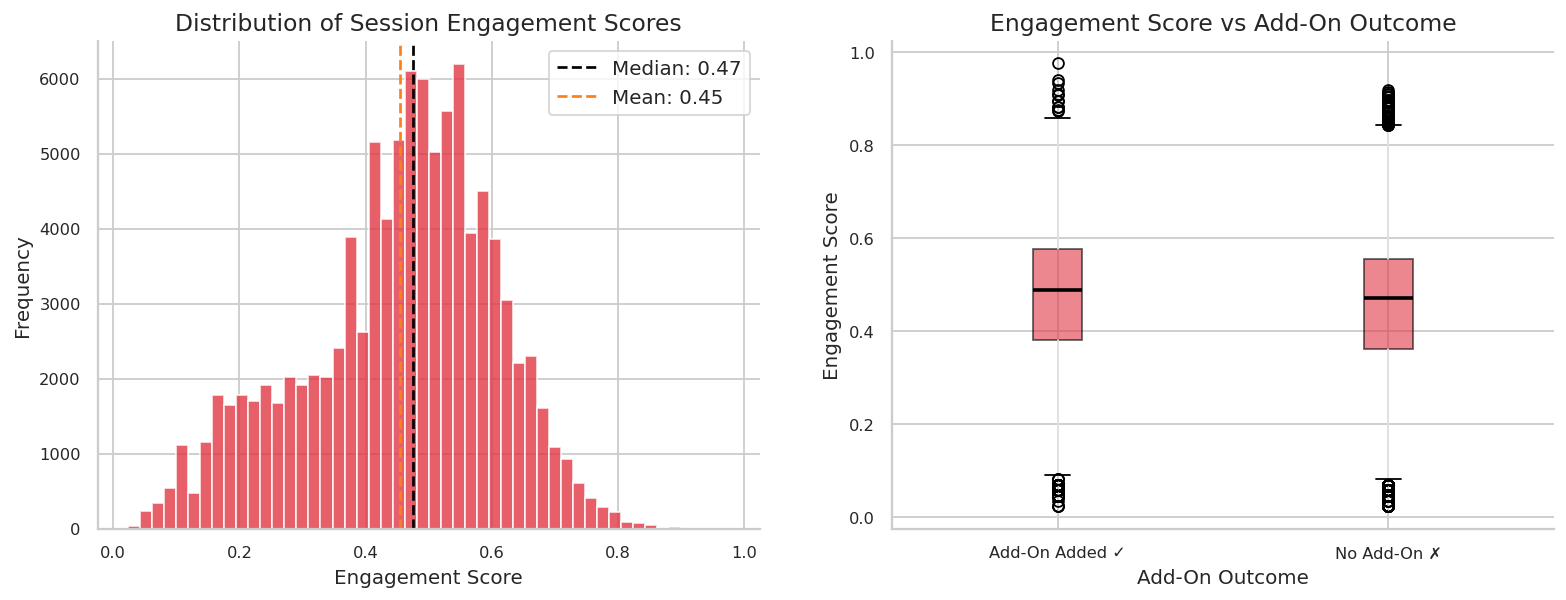

In [45]:
# -------------------------------
# Session Engagement Score Analysis
# -------------------------------

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Add overall title
fig.suptitle('Session Engagement Score Analysis', fontsize=14, fontweight='bold')


# -------------------------------
# 1. Histogram of engagement score
# -------------------------------

# Plot histogram of session engagement scores
axes[0].hist(
    df['session_engagement_score'],
    bins=50,
    color=ZOMATO_RED,
    alpha=0.8,
    edgecolor='white'
)

# Add median line
axes[0].axvline(
    df['session_engagement_score'].median(),
    color='black',
    linestyle='--',
    linewidth=1.5,
    label=f"Median: {df['session_engagement_score'].median():.2f}"
)

# Add mean line
axes[0].axvline(
    df['session_engagement_score'].mean(),
    color=ZOMATO_ORG,
    linestyle='--',
    linewidth=1.5,
    label=f"Mean: {df['session_engagement_score'].mean():.2f}"
)

# Set labels and title
axes[0].set_xlabel('Engagement Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Session Engagement Scores')

# Show legend
axes[0].legend()


# -------------------------------
# 2. Boxplot by add-on outcome
# -------------------------------

# Create a readable label for add-on outcome
df['Addon Outcome'] = df['any_addon_added'].map({
    1: 'Add-On Added ✓',
    0: 'No Add-On ✗'
})

# Plot boxplot comparing engagement score by add-on outcome
df.boxplot(
    column='session_engagement_score',
    by='Addon Outcome',
    ax=axes[1],
    patch_artist=True,
    boxprops=dict(facecolor=ZOMATO_RED, alpha=0.6),
    medianprops=dict(color='black', linewidth=2)
)

# Set labels and title
axes[1].set_title('Engagement Score vs Add-On Outcome')
axes[1].set_xlabel('Add-On Outcome')
axes[1].set_ylabel('Engagement Score')


# Remove automatic pandas subtitle
plt.suptitle('')


# -------------------------------
# Save the figure
# -------------------------------

savefig('03_engagement_score.png', fig)

This code analyzes the session engagement score using two visualizations: a histogram to show its overall distribution and a boxplot to compare engagement scores between sessions where an add-on was added and sessions where it was not. The final figure is then saved.

Saved: D:\Data Analytics\Project 2\Output\04_addon_analysis.png


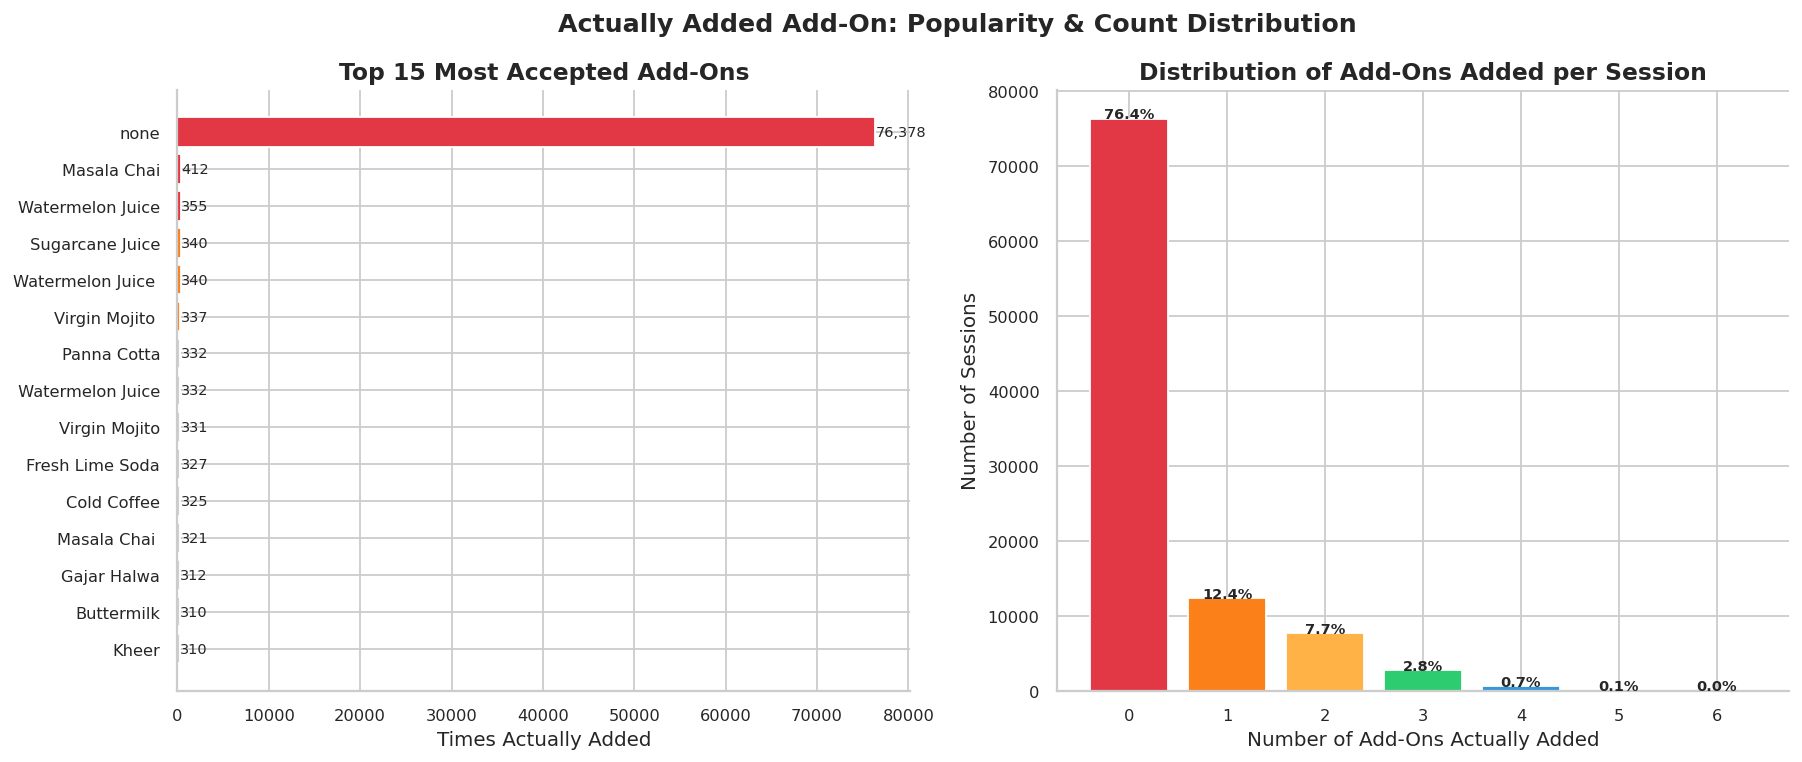

In [47]:
# -------------------------------
# Add-On Popularity & Count Analysis
# -------------------------------

# Create an empty list to store all accepted add-on names
all_addons = []

# Loop through each entry in the actual_added_addon_names column
for entry in df['actual_added_addon_names']:
    val = str(entry)

    # Ignore empty or missing values
    if val not in ('None', 'nan', ''):
        # Split multiple add-ons separated by "|" and add them to the list
        all_addons.extend(val.split('|'))

# Count frequency of each add-on
addon_freq = Counter(all_addons)

# Convert top 15 most common add-ons into a DataFrame
addon_df = pd.DataFrame(
    addon_freq.most_common(15),
    columns=['Add-On', 'Frequency']
)


# -------------------------------
# Create figure with 2 subplots
# -------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'Actually Added Add-On: Popularity & Count Distribution',
    fontsize=14,
    fontweight='bold'
)


# -------------------------------
# 1. Horizontal bar chart of top add-ons
# -------------------------------

# Highlight top 3 in red, next 3 in orange, rest in gray
colors_bar = [
    ZOMATO_RED if i < 3 else ZOMATO_ORG if i < 6 else '#D0D0D0'
    for i in range(len(addon_df))
]

# Plot horizontal bar chart
bars = axes[0].barh(
    addon_df['Add-On'][::-1],
    addon_df['Frequency'][::-1],
    color=colors_bar[::-1],
    edgecolor='white'
)

axes[0].set_xlabel('Times Actually Added')
axes[0].set_title('Top 15 Most Accepted Add-Ons', fontweight='bold')

# Add frequency labels beside bars
for bar, val in zip(bars, addon_df['Frequency'][::-1]):
    axes[0].text(
        val + 10,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,}',
        va='center',
        fontsize=8
    )


# -------------------------------
# 2. Distribution of add-on counts per session
# -------------------------------

# Count how many sessions had 0, 1, 2... add-ons added
addon_cnt_dist = df['actual_added_addon_count'].value_counts().sort_index()

# Plot bar chart
axes[1].bar(
    addon_cnt_dist.index.astype(str),
    addon_cnt_dist.values,
    color=PALETTE[:len(addon_cnt_dist)],
    edgecolor='white'
)

axes[1].set_xlabel('Number of Add-Ons Actually Added')
axes[1].set_ylabel('Number of Sessions')
axes[1].set_title('Distribution of Add-Ons Added per Session', fontweight='bold')

# Add percentage labels above bars
for i, (idx, val) in enumerate(addon_cnt_dist.items()):
    pct = val / len(df) * 100
    axes[1].text(
        i,
        val + 20,
        f'{pct:.1f}%',
        ha='center',
        fontsize=8,
        fontweight='bold'
    )


# -------------------------------
# Save the figure
# -------------------------------

savefig('04_addon_analysis.png', fig)

This code analyzes the actually added add-ons by extracting add-on names, counting how often each one was accepted, and plotting the top 15 most accepted add-ons. It also shows the distribution of how many add-ons were added per session.

Saved: D:\Data Analytics\Project 2\Output\04b_reco_addon_categories.png


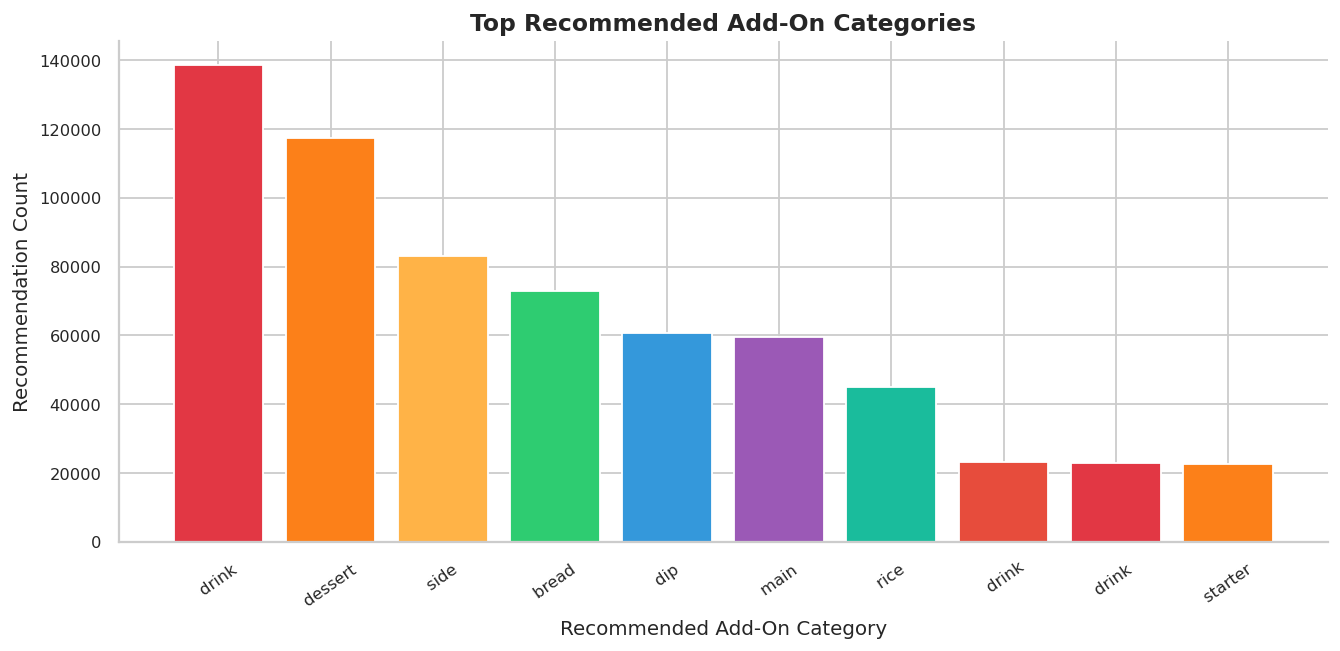

In [49]:
# -------------------------------
# Recommended Add-On Category Analysis
# -------------------------------

# Create an empty list to store all recommended add-on categories
all_reco_cats = []

# Loop through each entry in the recommended_addon_categories column
for entry in df['recommended_addon_categories']:
    val = str(entry)

    # Ignore missing or empty values
    if val not in ('None', 'nan', ''):
        # Split multiple categories separated by "|" and add them to the list
        all_reco_cats.extend(val.split('|'))

# Count frequency of each recommended category
reco_cat_freq = Counter(all_reco_cats)

# Convert top 10 most common categories into a DataFrame
reco_cat_df = pd.DataFrame(
    reco_cat_freq.most_common(10),
    columns=['Category', 'Count']
)

# Create figure
fig, ax = plt.subplots(figsize=(12, 5))

# Plot bar chart
ax.bar(
    reco_cat_df['Category'],
    reco_cat_df['Count'],
    color=PALETTE[:len(reco_cat_df)],
    edgecolor='white'
)

# Add labels and title
ax.set_xlabel('Recommended Add-On Category')
ax.set_ylabel('Recommendation Count')
ax.set_title('Top Recommended Add-On Categories', fontweight='bold')

# Rotate x-axis labels for readability
ax.tick_params(axis='x', rotation=35)

# Save the figure
savefig('04b_reco_addon_categories.png', fig)

This code extracts all recommended add-on categories, counts how often each category appears, selects the top 10 categories, and visualizes them using a bar chart.

Saved: D:\Data Analytics\Project 2\Output\05_time_based_behavior.png


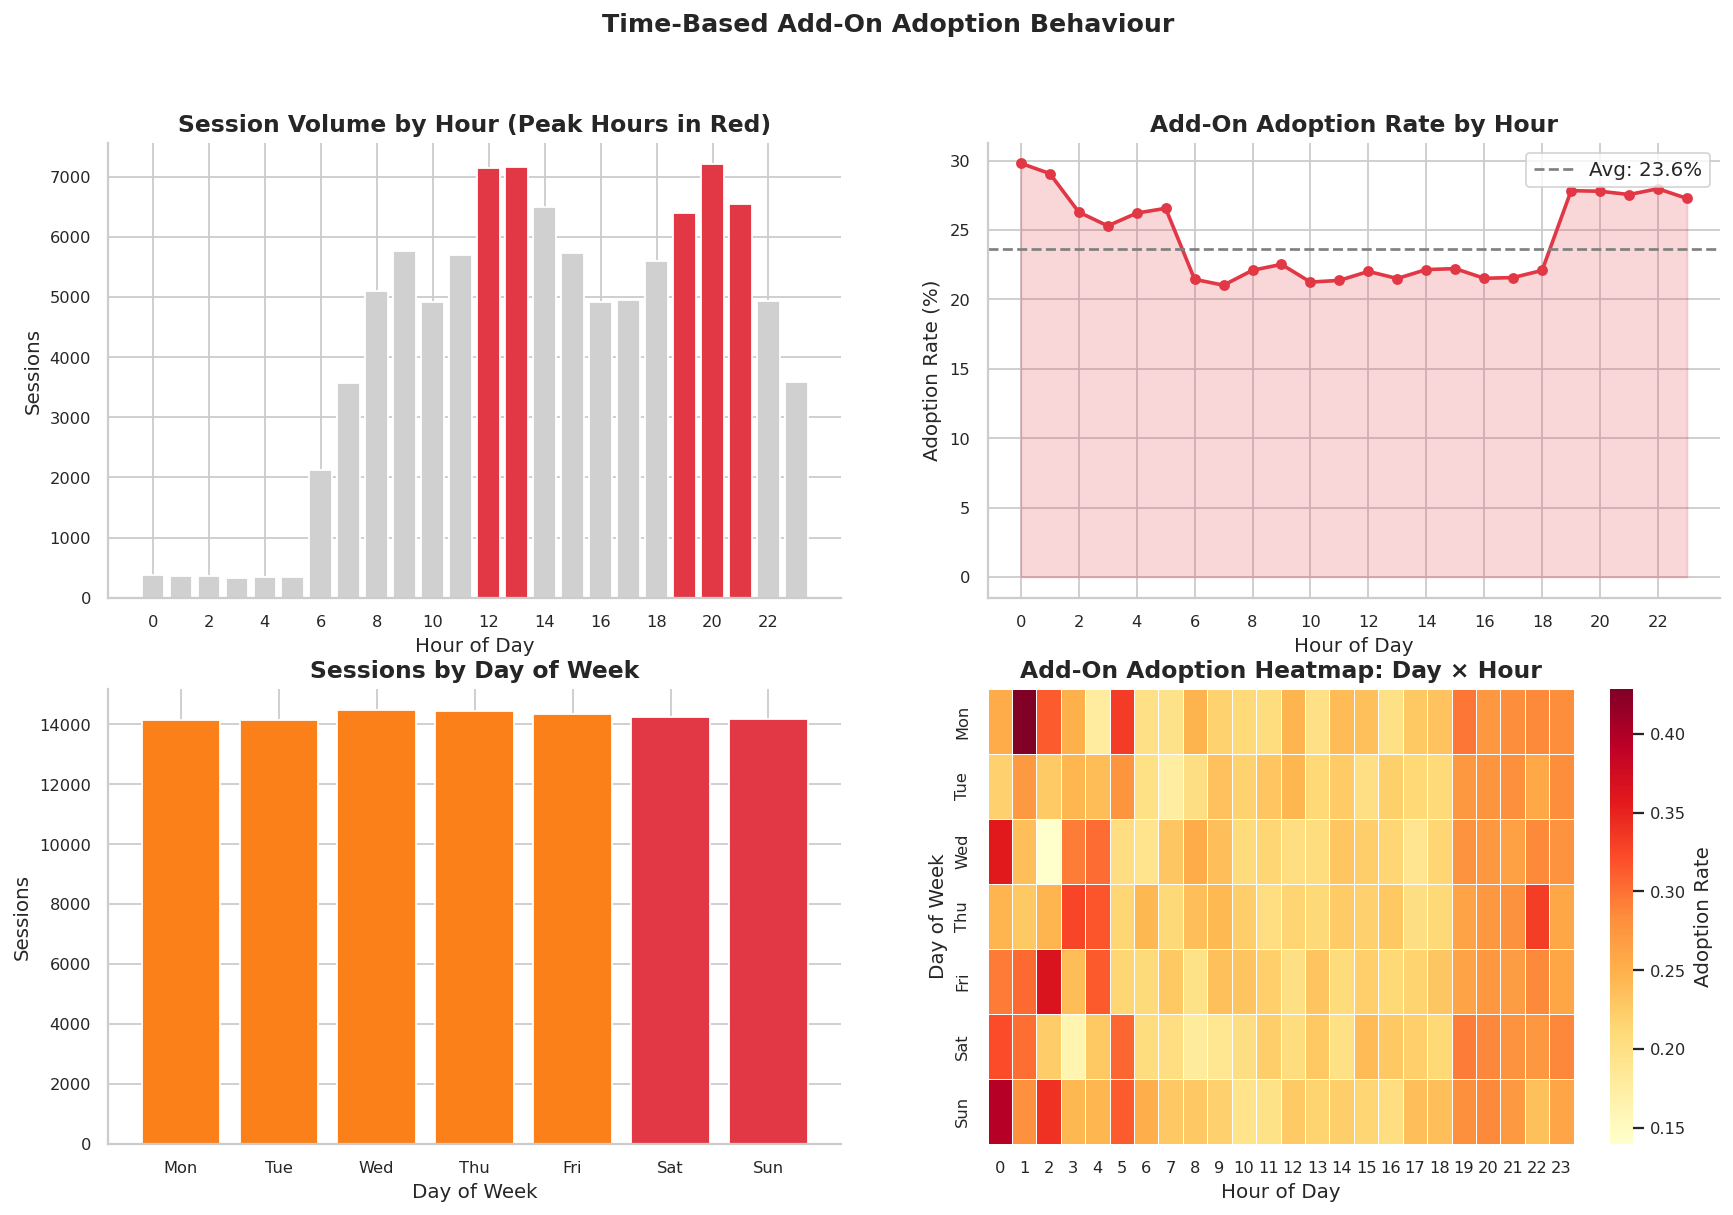

In [50]:
# -------------------------------
# Time-Based Add-On Adoption Behaviour
# -------------------------------

# Create a 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Time-Based Add-On Adoption Behaviour', fontsize=14, fontweight='bold')


# -------------------------------
# 1. Hourly session volume
# -------------------------------

# Count number of sessions for each hour
hourly = df.groupby('hour').size().reset_index(name='sessions')

# Calculate add-on adoption rate for each hour
hourly_adopt = df.groupby('hour')['any_addon_added'].mean().reset_index()

# Define peak hours to highlight
peak_hours = [12, 13, 19, 20, 21]

# Plot hourly session volume
axes[0, 0].bar(
    hourly['hour'],
    hourly['sessions'],
    color=[ZOMATO_RED if h in peak_hours else '#D0D0D0' for h in hourly['hour']],
    edgecolor='white'
)

axes[0, 0].set_xlabel('Hour of Day')
axes[0, 0].set_ylabel('Sessions')
axes[0, 0].set_title('Session Volume by Hour (Peak Hours in Red)', fontweight='bold')
axes[0, 0].set_xticks(range(0, 24, 2))


# -------------------------------
# 2. Add-on adoption rate by hour
# -------------------------------

# Plot adoption rate line chart
axes[0, 1].plot(
    hourly_adopt['hour'],
    hourly_adopt['any_addon_added'] * 100,
    color=ZOMATO_RED,
    linewidth=2,
    marker='o',
    markersize=5
)

# Fill area under the line
axes[0, 1].fill_between(
    hourly_adopt['hour'],
    hourly_adopt['any_addon_added'] * 100,
    alpha=0.2,
    color=ZOMATO_RED
)

axes[0, 1].set_xlabel('Hour of Day')
axes[0, 1].set_ylabel('Adoption Rate (%)')
axes[0, 1].set_title('Add-On Adoption Rate by Hour', fontweight='bold')
axes[0, 1].set_xticks(range(0, 24, 2))

# Add average adoption rate reference line
axes[0, 1].axhline(
    df['any_addon_added'].mean() * 100,
    color='grey',
    linestyle='--',
    label=f"Avg: {df['any_addon_added'].mean() * 100:.1f}%"
)

axes[0, 1].legend()


# -------------------------------
# 3. Sessions by day of week
# -------------------------------

# Aggregate session count and adoption rate by day
daily = df.groupby('day_name').agg(
    sessions=('session_id', 'count'),
    adopt_rate=('any_addon_added', 'mean')
).reindex(DAY_ORDER).reset_index()

# Highlight weekend bars differently
bar_colors = [ZOMATO_RED if d in ['Sat', 'Sun'] else ZOMATO_ORG for d in DAY_ORDER]

# Plot day-wise session counts
axes[1, 0].bar(
    daily['day_name'],
    daily['sessions'],
    color=bar_colors,
    edgecolor='white'
)

axes[1, 0].set_xlabel('Day of Week')
axes[1, 0].set_ylabel('Sessions')
axes[1, 0].set_title('Sessions by Day of Week', fontweight='bold')


# -------------------------------
# 4. Heatmap of day × hour adoption rate
# -------------------------------

# Create pivot table of adoption rate by day and hour
pivot = df.groupby(['day_name', 'hour'])['any_addon_added'].mean().unstack()

# Reorder days properly
pivot = pivot.reindex(DAY_ORDER)

# Plot heatmap
sns.heatmap(
    pivot,
    ax=axes[1, 1],
    cmap='YlOrRd',
    fmt='.2f',
    annot=False,
    linewidths=0.3,
    cbar_kws={'label': 'Adoption Rate'}
)

axes[1, 1].set_title('Add-On Adoption Heatmap: Day × Hour', fontweight='bold')
axes[1, 1].set_xlabel('Hour of Day')
axes[1, 1].set_ylabel('Day of Week')


# -------------------------------
# Save the figure
# -------------------------------

savefig('05_time_based_behavior.png', fig)

This code analyzes time-based add-on adoption behavior using four plots. It shows session volume by hour, add-on adoption rate by hour, session distribution by day of the week, and a heatmap of adoption rate across day-hour combinations.

Saved: D:\Data Analytics\Project 2\Output\05b_meal_time_analysis.png


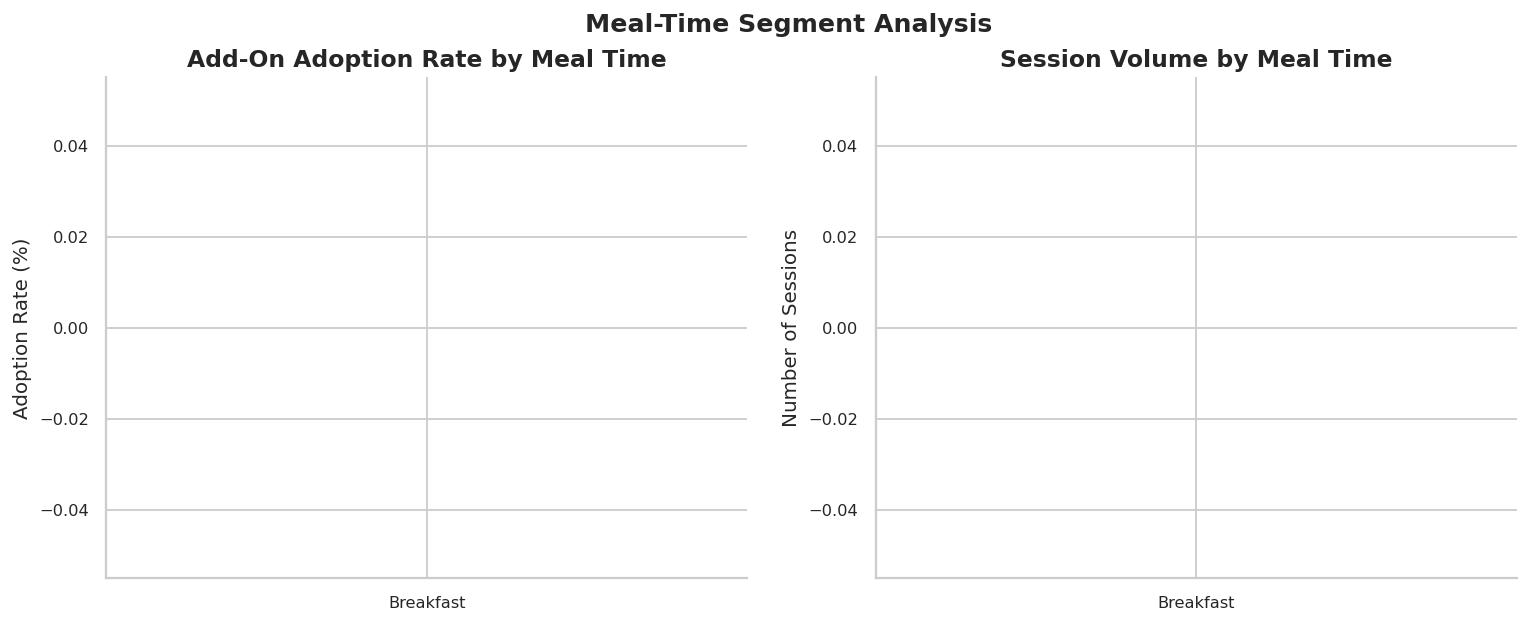

In [51]:
# -------------------------------
# Meal-Time Segment Analysis
# -------------------------------

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Meal-Time Segment Analysis', fontsize=14, fontweight='bold')

# Define custom order for meal times
seg_order = ['Breakfast', 'Lunch', 'Snack', 'Dinner', 'Late Night']

# Calculate add-on adoption rate (%) by meal time
seg_adopt = df.groupby('meal_time')['any_addon_added'].mean().reindex(seg_order) * 100

# Calculate number of sessions by meal time
seg_vol = df.groupby('meal_time').size().reindex(seg_order)


# -------------------------------
# 1. Add-on adoption rate by meal time
# -------------------------------

axes[0].bar(
    seg_adopt.index,
    seg_adopt.values,
    color=[ZOMATO_RED if v == seg_adopt.max() else ZOMATO_ORG for v in seg_adopt.values],
    edgecolor='white'
)

axes[0].set_ylabel('Adoption Rate (%)')
axes[0].set_title('Add-On Adoption Rate by Meal Time', fontweight='bold')

# Add percentage labels on top of bars
for i, val in enumerate(seg_adopt.values):
    axes[0].text(
        i,
        val + 0.3,
        f'{val:.1f}%',
        ha='center',
        fontweight='bold',
        fontsize=9
    )


# -------------------------------
# 2. Session volume by meal time
# -------------------------------

axes[1].bar(
    seg_vol.index,
    seg_vol.values,
    color=PALETTE[:5],
    edgecolor='white'
)

axes[1].set_ylabel('Number of Sessions')
axes[1].set_title('Session Volume by Meal Time', fontweight='bold')

# Add count labels on top of bars
for i, val in enumerate(seg_vol.values):
    axes[1].text(
        i,
        val + 50,
        f'{val:,}',
        ha='center',
        fontsize=8,
        fontweight='bold'
    )

# Save the figure
savefig('05b_meal_time_analysis.png', fig)

This code analyzes meal-time patterns by showing the add-on adoption rate and session volume for different meal periods like breakfast, lunch, and dinner. It uses two bar charts and highlights the meal time with the highest adoption rate.

Saved: D:\Data Analytics\Project 2\Output\06_revenue_impact.png


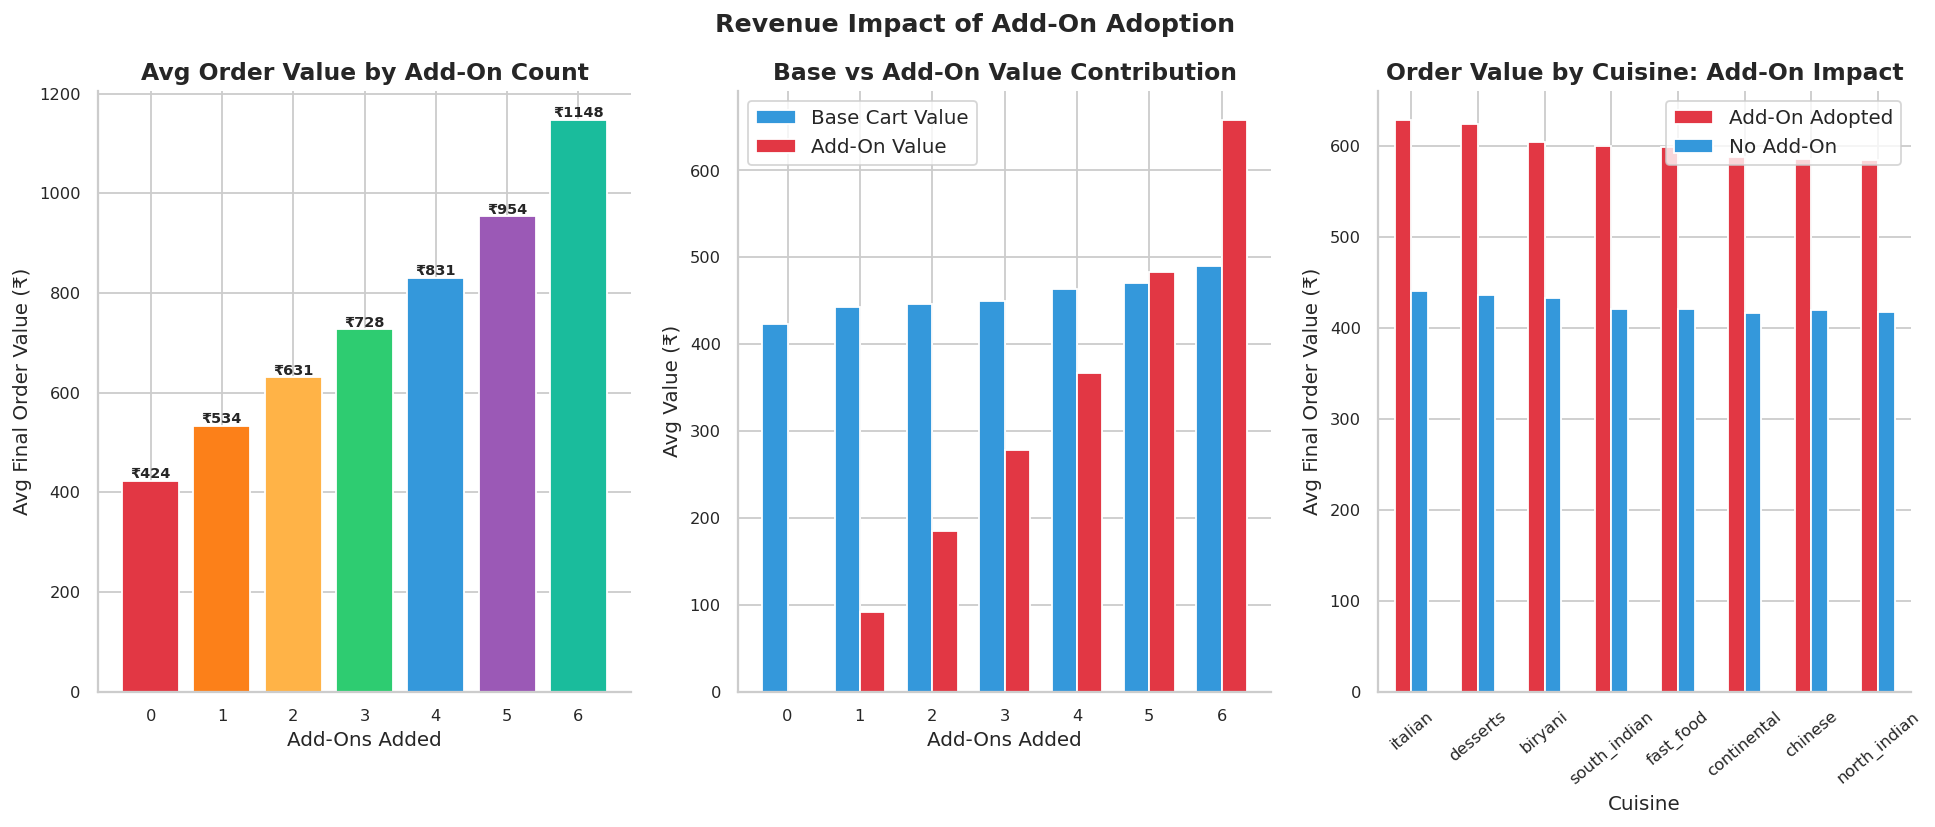

In [52]:
# -------------------------------
# Revenue Impact of Add-On Adoption
# -------------------------------

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Revenue Impact of Add-On Adoption', fontsize=14, fontweight='bold')


# -------------------------------
# 1. Average final order value by add-on count
# -------------------------------

# Calculate average final order value for each add-on count
fov_by_addon = df.groupby('actual_added_addon_count')['final_order_value'].mean()

# Plot bar chart
axes[0].bar(
    fov_by_addon.index.astype(str),
    fov_by_addon.values,
    color=PALETTE[:len(fov_by_addon)],
    edgecolor='white'
)

axes[0].set_xlabel('Add-Ons Added')
axes[0].set_ylabel('Avg Final Order Value (₹)')
axes[0].set_title('Avg Order Value by Add-On Count', fontweight='bold')

# Add value labels above bars
for i, (idx, val) in enumerate(fov_by_addon.items()):
    axes[0].text(i, val + 5, f'₹{val:.0f}', ha='center', fontsize=8, fontweight='bold')


# -------------------------------
# 2. Base cart value vs add-on value contribution
# -------------------------------

# Calculate average base cart value and add-on value by add-on count
val_contrib = df.groupby('actual_added_addon_count').agg(
    base=('base_cart_value', 'mean'),
    addon=('actual_added_addon_value', 'mean')
)

# Create x positions and bar width
x = np.arange(len(val_contrib))
w = 0.35

# Plot grouped bars
axes[1].bar(
    x - w / 2,
    val_contrib['base'],
    w,
    label='Base Cart Value',
    color='#3498DB',
    edgecolor='white'
)

axes[1].bar(
    x + w / 2,
    val_contrib['addon'],
    w,
    label='Add-On Value',
    color=ZOMATO_RED,
    edgecolor='white'
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(val_contrib.index.astype(str))
axes[1].set_xlabel('Add-Ons Added')
axes[1].set_ylabel('Avg Value (₹)')
axes[1].set_title('Base vs Add-On Value Contribution', fontweight='bold')
axes[1].legend()


# -------------------------------
# 3. Final order value by cuisine and add-on adoption
# -------------------------------

# Create readable label for add-on adoption
df['has_addon_label'] = df['any_addon_added'].map({
    1: 'Add-On Adopted',
    0: 'No Add-On'
})

# Compute average final order value by cuisine and add-on label
cuis_rev = df.groupby(['restaurant_cuisine', 'has_addon_label'])['final_order_value'].mean().unstack()

# Select top 8 cuisines based on "Add-On Adopted" value if available
if 'Add-On Adopted' in cuis_rev.columns:
    cuis_rev_top = cuis_rev.nlargest(8, 'Add-On Adopted')
else:
    cuis_rev_top = cuis_rev.head(8)

# Plot grouped bar chart
cuis_rev_top.plot(
    kind='bar',
    ax=axes[2],
    color=[ZOMATO_RED, '#3498DB'],
    edgecolor='white',
    rot=40
)

axes[2].set_xlabel('Cuisine')
axes[2].set_ylabel('Avg Final Order Value (₹)')
axes[2].set_title('Order Value by Cuisine: Add-On Impact', fontweight='bold')
axes[2].legend(title='')


# -------------------------------
# Save the figure
# -------------------------------

savefig('06_revenue_impact.png', fig)

This code analyzes the revenue impact of add-on adoption using three plots. It shows how final order value changes with the number of add-ons, compares base cart value with add-on value, and compares average final order value across cuisines based on whether an add-on was adopted.

Saved: D:\Data Analytics\Project 2\Output\07_reco_quality_analysis.png


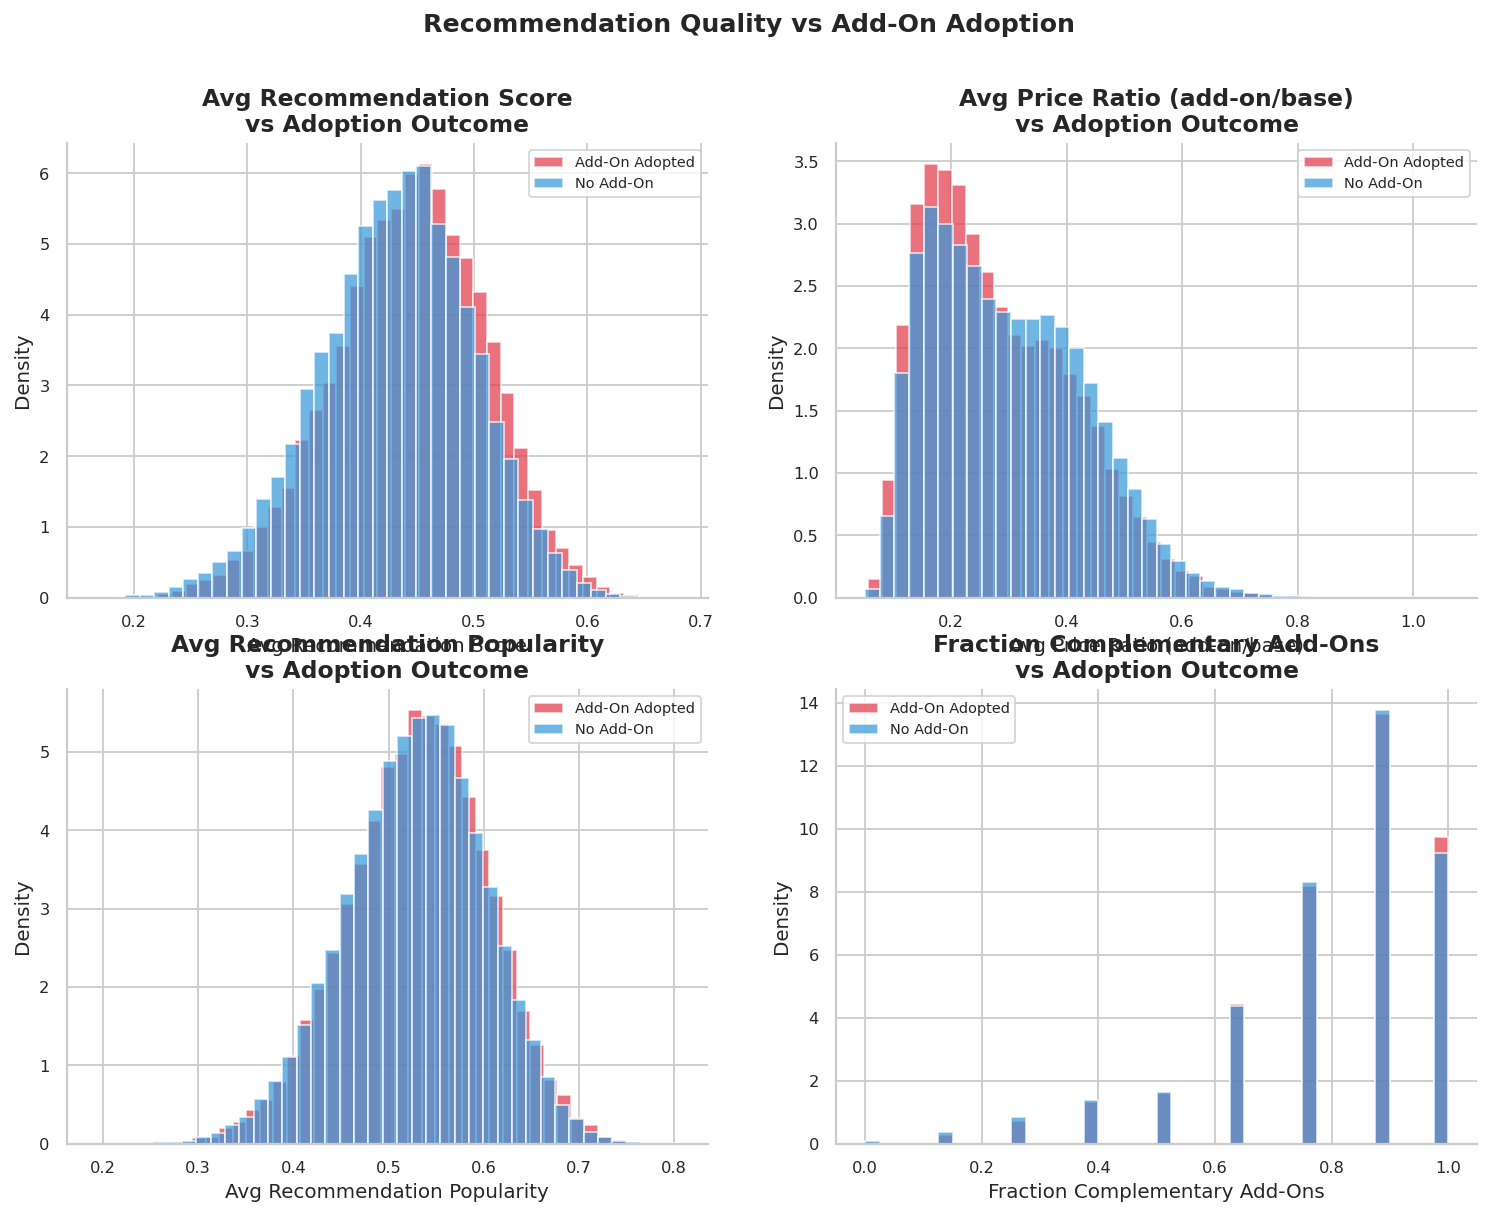

In [53]:
# -------------------------------
# Recommendation Quality vs Add-On Adoption
# -------------------------------

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Recommendation Quality vs Add-On Adoption', fontsize=14, fontweight='bold')

# Define recommendation metrics to analyze
reco_metrics = [
    ('avg_reco_score', 'Avg Recommendation Score', axes[0, 0]),
    ('avg_reco_price_ratio', 'Avg Price Ratio (add-on/base)', axes[0, 1]),
    ('avg_reco_popularity', 'Avg Recommendation Popularity', axes[1, 0]),
    ('avg_reco_is_complementary', 'Fraction Complementary Add-Ons', axes[1, 1]),
]

# Loop through each recommendation metric
for col, label, ax in reco_metrics:
    
    # Split data based on whether add-on was adopted
    adopted = df[df['any_addon_added'] == 1][col]
    not_adopted = df[df['any_addon_added'] == 0][col]

    # Plot histogram for adopted sessions
    ax.hist(
        adopted,
        bins=40,
        alpha=0.7,
        color=ZOMATO_RED,
        label='Add-On Adopted',
        density=True
    )

    # Plot histogram for non-adopted sessions
    ax.hist(
        not_adopted,
        bins=40,
        alpha=0.7,
        color='#3498DB',
        label='No Add-On',
        density=True
    )

    # Set labels and title
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.set_title(f'{label}\nvs Adoption Outcome', fontweight='bold')
    ax.legend(fontsize=8)

# Save the figure
savefig('07_reco_quality_analysis.png', fig)

This code compares different recommendation quality metrics for sessions where an add-on was adopted versus not adopted. It plots histograms for each metric to see how recommendation quality relates to add-on acceptance.

Saved: D:\Data Analytics\Project 2\Output\08_contextual_signals.png


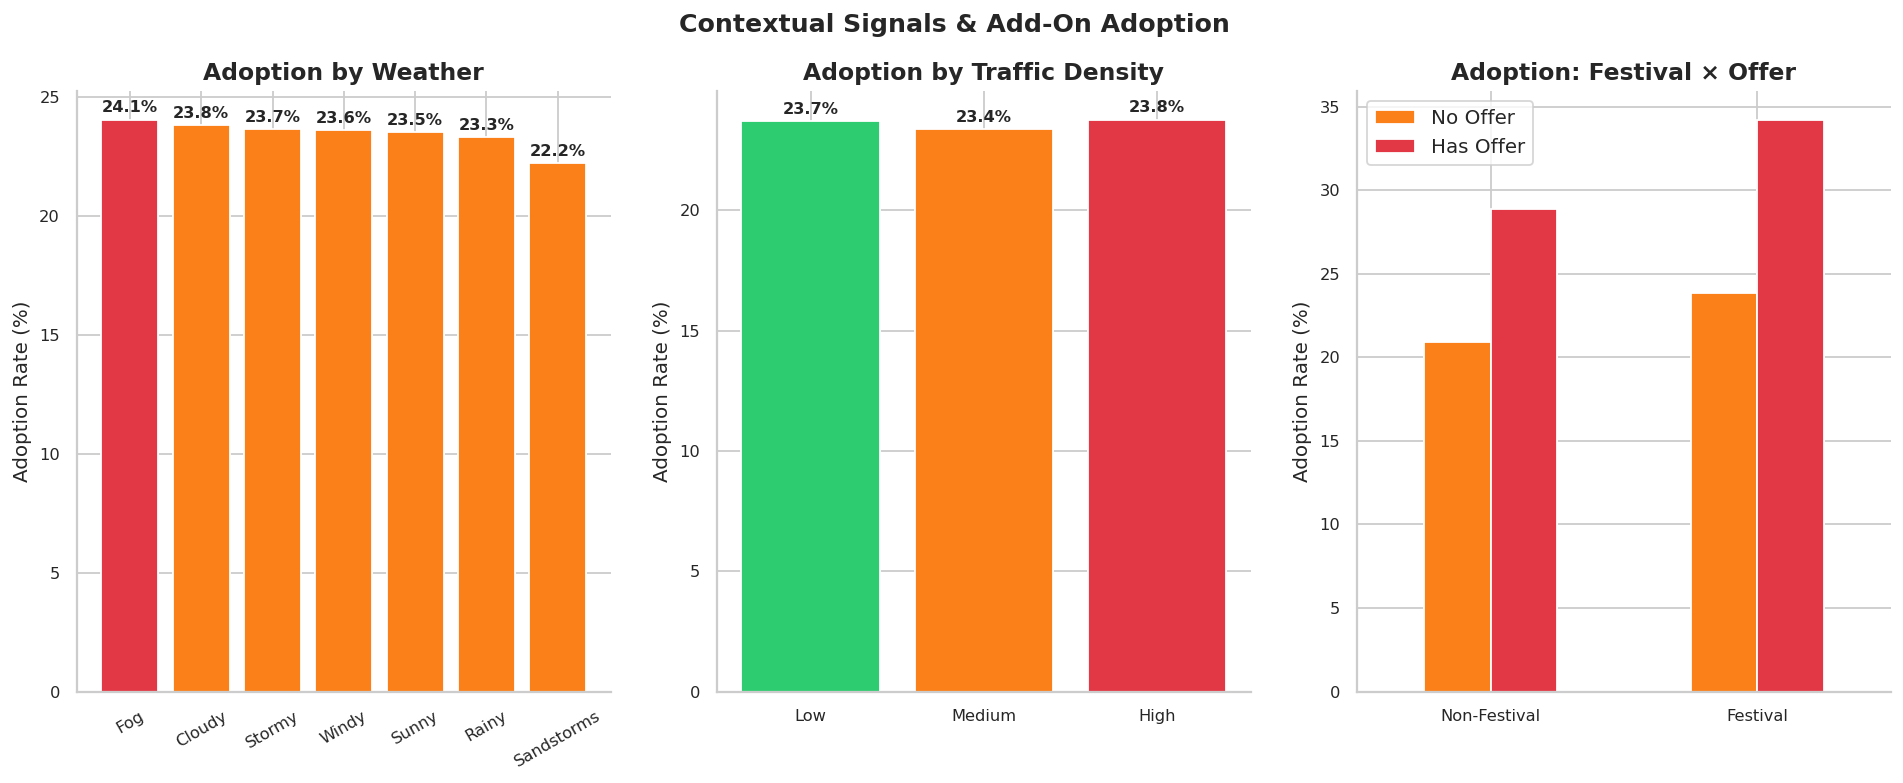

In [54]:
# -------------------------------
# Contextual Signals & Add-On Adoption
# -------------------------------

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Contextual Signals & Add-On Adoption', fontsize=14, fontweight='bold')


# -------------------------------
# 1. Adoption rate by weather
# -------------------------------

# Calculate adoption rate for each weather condition
weather_adopt = df.groupby('weather_condition')['any_addon_added'].mean() * 100

# Sort values from highest to lowest
weather_adopt = weather_adopt.sort_values(ascending=False)

# Plot bar chart
axes[0].bar(
    weather_adopt.index,
    weather_adopt.values,
    color=[ZOMATO_RED if v == weather_adopt.max() else ZOMATO_ORG for v in weather_adopt.values],
    edgecolor='white'
)

axes[0].set_ylabel('Adoption Rate (%)')
axes[0].set_title('Adoption by Weather', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

# Add percentage labels above bars
for i, val in enumerate(weather_adopt.values):
    axes[0].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')


# -------------------------------
# 2. Adoption rate by traffic density
# -------------------------------

# Calculate adoption rate by traffic level
traffic_adopt = df.groupby('traffic_density')['any_addon_added'].mean() * 100

# Define desired order
traffic_order = ['Low', 'Medium', 'High']

# Reorder traffic levels if present
traffic_adopt = traffic_adopt.reindex([t for t in traffic_order if t in traffic_adopt.index])

# Plot bar chart
axes[1].bar(
    traffic_adopt.index,
    traffic_adopt.values,
    color=['#2ECC71', ZOMATO_ORG, ZOMATO_RED][:len(traffic_adopt)],
    edgecolor='white'
)

axes[1].set_ylabel('Adoption Rate (%)')
axes[1].set_title('Adoption by Traffic Density', fontweight='bold')

# Add percentage labels above bars
for i, val in enumerate(traffic_adopt.values):
    axes[1].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')


# -------------------------------
# 3. Adoption rate by festival day and offer
# -------------------------------

# Calculate adoption rate for festival/non-festival and offer/no-offer combinations
ctx_df = df.groupby(['is_festival_day', 'has_offer'])['any_addon_added'].mean().unstack() * 100

# Rename index and columns for readability
ctx_df.index = ['Non-Festival', 'Festival']
ctx_df.columns = ['No Offer', 'Has Offer']

# Plot grouped bar chart
ctx_df.plot(
    kind='bar',
    ax=axes[2],
    color=[ZOMATO_ORG, ZOMATO_RED],
    edgecolor='white',
    rot=0
)

axes[2].set_ylabel('Adoption Rate (%)')
axes[2].set_title('Adoption: Festival × Offer', fontweight='bold')
axes[2].legend(title='')


# -------------------------------
# Save the figure
# -------------------------------

savefig('08_contextual_signals.png', fig)

This code analyzes how contextual factors like weather, traffic, and festival/offer combinations affect add-on adoption. It creates three bar charts to compare adoption rates across these different conditions.

Saved: D:\Data Analytics\Project 2\Output\09_cart_composition.png


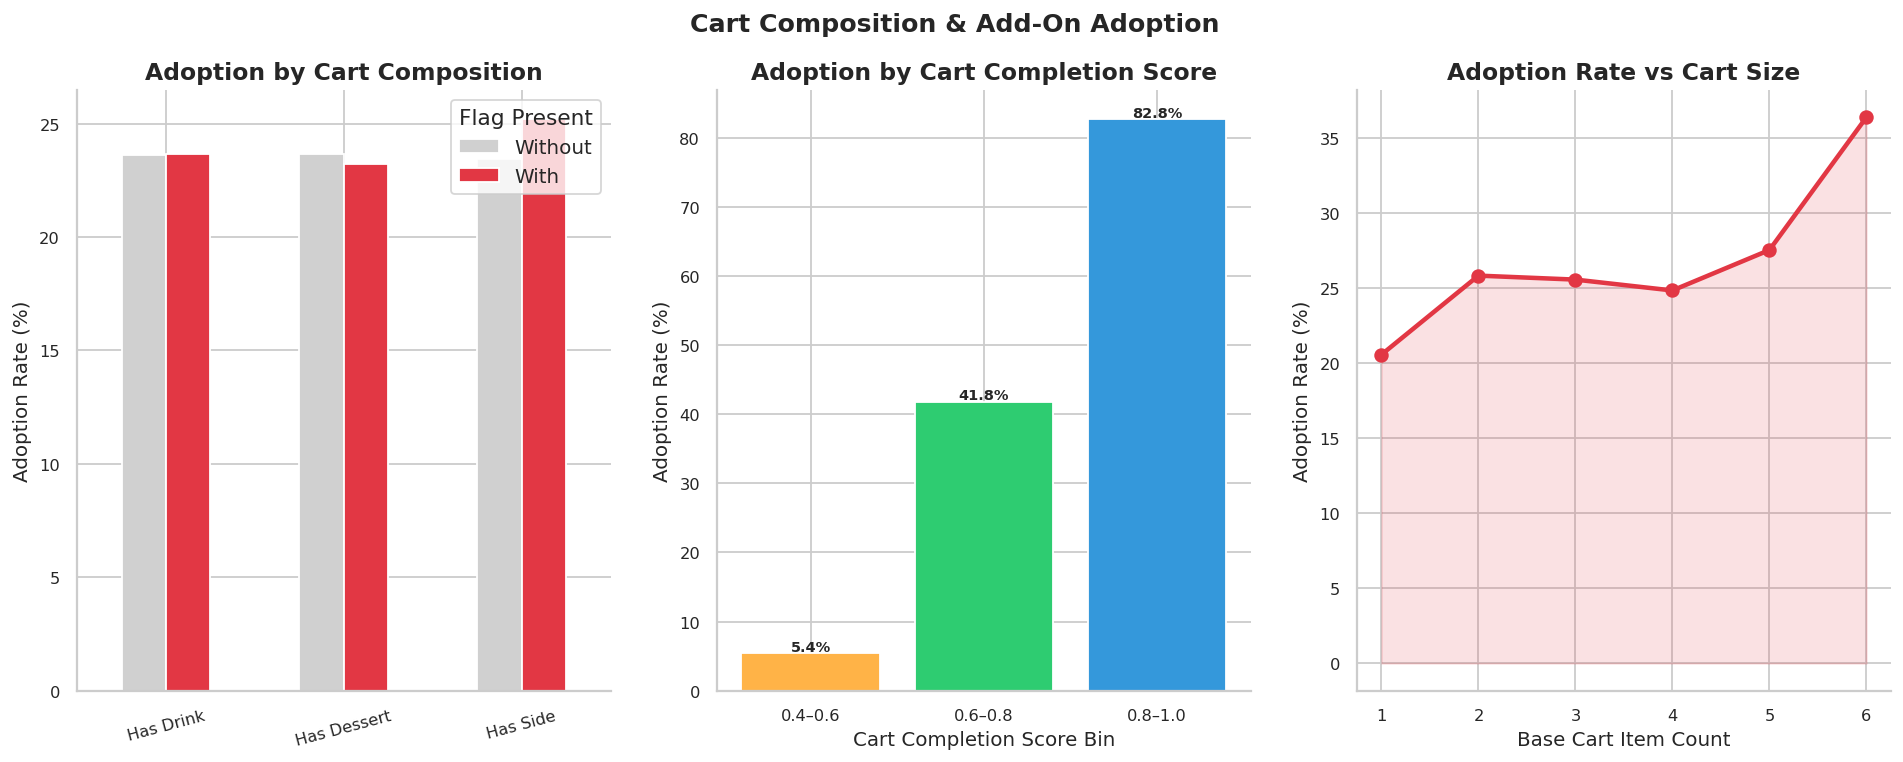

In [55]:
# -------------------------------
# Cart Composition & Add-On Adoption
# -------------------------------

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Cart Composition & Add-On Adoption', fontsize=14, fontweight='bold')


# -------------------------------
# 1. Cart flags vs adoption
# -------------------------------

# Define cart-related binary flags and their display labels
cart_flags = {
    'cart_has_drink': 'Has Drink',
    'cart_has_dessert': 'Has Dessert',
    'cart_has_side': 'Has Side'
}

# Calculate adoption rate for sessions without and with each flag
flag_adopt = {
    label: [
        df[df[col] == 0]['any_addon_added'].mean() * 100,
        df[df[col] == 1]['any_addon_added'].mean() * 100
    ]
    for col, label in cart_flags.items()
}

# Convert results to DataFrame
flag_df = pd.DataFrame(flag_adopt, index=['Without', 'With']).T

# Plot grouped bar chart
flag_df.plot(
    kind='bar',
    ax=axes[0],
    color=['#D0D0D0', ZOMATO_RED],
    edgecolor='white',
    rot=15
)

axes[0].set_ylabel('Adoption Rate (%)')
axes[0].set_title('Adoption by Cart Composition', fontweight='bold')
axes[0].legend(title='Flag Present')


# -------------------------------
# 2. Cart completion score vs adoption
# -------------------------------

# Define bins for cart completion score
bins = [0, 0.2, 0.4, 0.6, 0.8, 1.01]
labels_cc = ['0–0.2', '0.2–0.4', '0.4–0.6', '0.6–0.8', '0.8–1.0']

# Create binned category column
df['completion_bin'] = pd.cut(df['cart_completion_score'], bins=bins, labels=labels_cc)

# Calculate adoption rate for each completion score bin
cc_adopt = df.groupby('completion_bin')['any_addon_added'].mean() * 100

# Plot bar chart
axes[1].bar(
    cc_adopt.index,
    cc_adopt.values,
    color=PALETTE[:len(cc_adopt)],
    edgecolor='white'
)

axes[1].set_xlabel('Cart Completion Score Bin')
axes[1].set_ylabel('Adoption Rate (%)')
axes[1].set_title('Adoption by Cart Completion Score', fontweight='bold')

# Add percentage labels above bars
for i, val in enumerate(cc_adopt.values):
    axes[1].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontsize=8, fontweight='bold')


# -------------------------------
# 3. Base cart item count vs adoption
# -------------------------------

# Calculate adoption rate by number of items in cart
item_adopt = df.groupby('base_cart_item_count')['any_addon_added'].mean() * 100

# Plot line chart
axes[2].plot(
    item_adopt.index,
    item_adopt.values,
    color=ZOMATO_RED,
    linewidth=2.5,
    marker='o',
    markersize=7
)

# Fill area below the line
axes[2].fill_between(
    item_adopt.index,
    item_adopt.values,
    alpha=0.15,
    color=ZOMATO_RED
)

axes[2].set_xlabel('Base Cart Item Count')
axes[2].set_ylabel('Adoption Rate (%)')
axes[2].set_title('Adoption Rate vs Cart Size', fontweight='bold')


# -------------------------------
# Save the figure
# -------------------------------

savefig('09_cart_composition.png', fig)

This code studies how cart composition affects add-on adoption. It compares adoption rates based on cart flags like drink, dessert, and side, checks adoption across cart completion score ranges, and shows how adoption changes with the number of items in the cart.

Saved: D:\Data Analytics\Project 2\Output\10_user_attributes.png


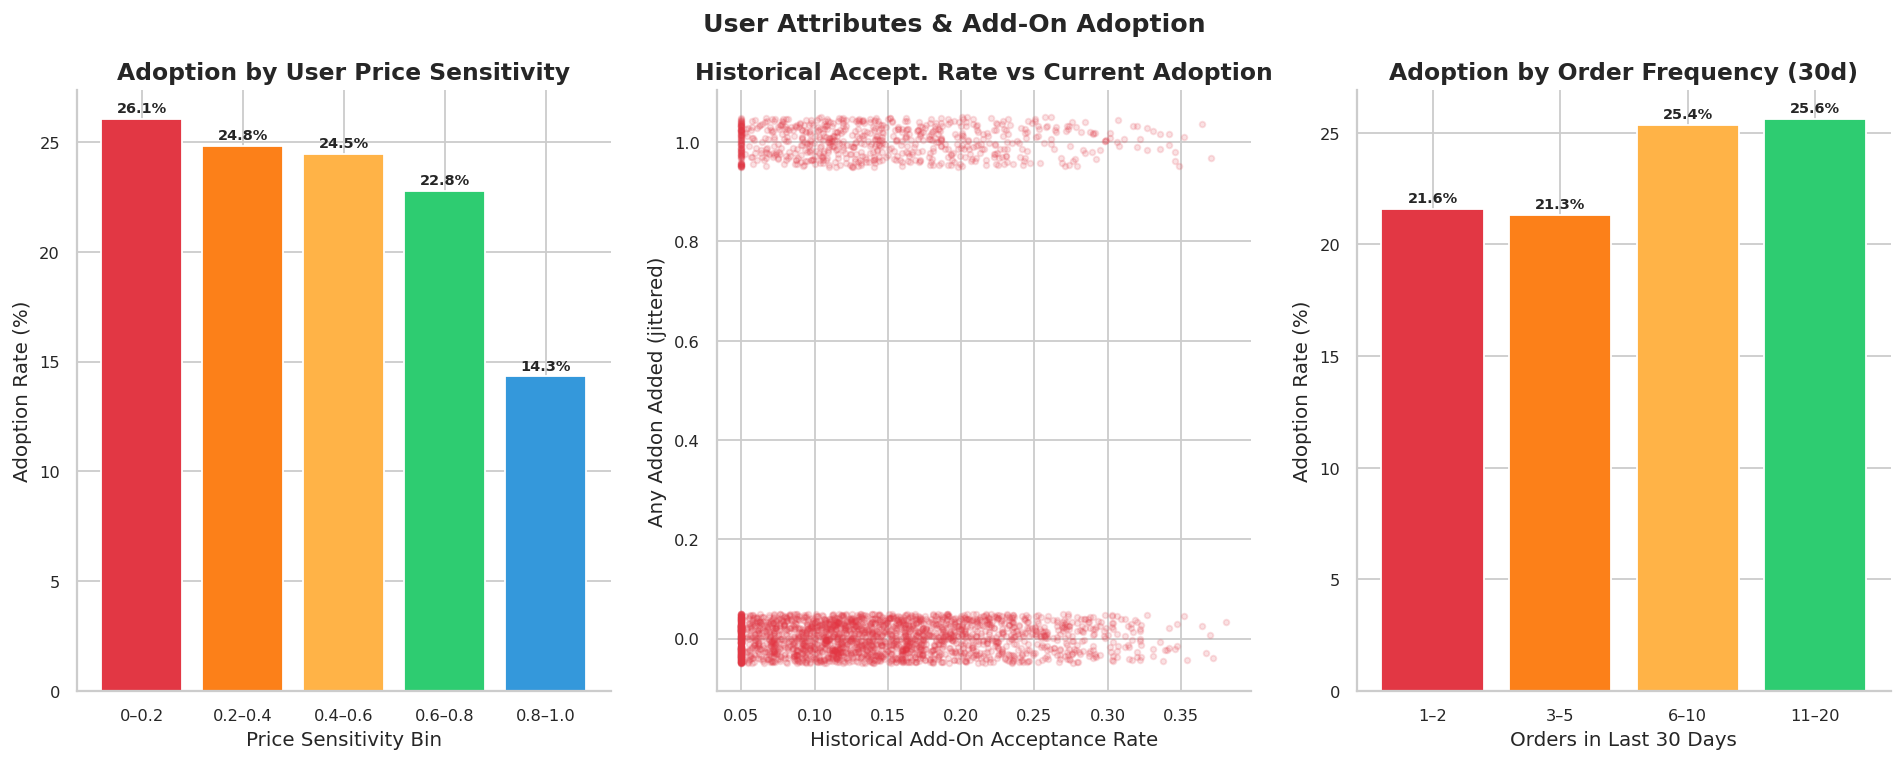

In [56]:
# -------------------------------
# User Attributes & Add-On Adoption
# -------------------------------

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('User Attributes & Add-On Adoption', fontsize=14, fontweight='bold')


# -------------------------------
# 1. User price sensitivity vs adoption
# -------------------------------

# Define bins and labels for price sensitivity
bins_ps = [0, 0.2, 0.4, 0.6, 0.8, 1.01]
labels_ps = ['0–0.2', '0.2–0.4', '0.4–0.6', '0.6–0.8', '0.8–1.0']

# Create binned price sensitivity column
df['price_sens_bin'] = pd.cut(
    df['user_price_sensitivity'],
    bins=bins_ps,
    labels=labels_ps
)

# Calculate adoption rate by price sensitivity bin
ps_adopt = df.groupby('price_sens_bin')['any_addon_added'].mean() * 100

# Plot bar chart
axes[0].bar(
    ps_adopt.index,
    ps_adopt.values,
    color=PALETTE[:len(ps_adopt)],
    edgecolor='white'
)

axes[0].set_xlabel('Price Sensitivity Bin')
axes[0].set_ylabel('Adoption Rate (%)')
axes[0].set_title('Adoption by User Price Sensitivity', fontweight='bold')

# Add percentage labels above bars
for i, val in enumerate(ps_adopt.values):
    axes[0].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontsize=8, fontweight='bold')


# -------------------------------
# 2. Historical acceptance rate vs current adoption
# -------------------------------

# Take a sample for scatter plot to avoid overplotting
sample = df.sample(min(3000, len(df)), random_state=42)

# Plot scatter with slight vertical jitter
axes[1].scatter(
    sample['user_addon_acceptance_rate'],
    sample['any_addon_added'] + np.random.uniform(-0.05, 0.05, len(sample)),
    alpha=0.15,
    color=ZOMATO_RED,
    s=10
)

axes[1].set_xlabel('Historical Add-On Acceptance Rate')
axes[1].set_ylabel('Any Addon Added (jittered)')
axes[1].set_title('Historical Accept. Rate vs Current Adoption', fontweight='bold')


# -------------------------------
# 3. Order frequency vs adoption
# -------------------------------

# Get maximum order frequency
max_freq = df['user_order_frequency_30d'].max()

# Define bins and labels for order frequency
bins_freq = [0, 2, 5, 10, 20, max(21, max_freq + 1)]
labels_freq = ['1–2', '3–5', '6–10', '11–20', '21+']

# Create binned frequency column
df['freq_bin'] = pd.cut(
    df['user_order_frequency_30d'],
    bins=bins_freq,
    labels=labels_freq,
    include_lowest=True
)

# Calculate adoption rate by order frequency bin
freq_adopt = df.groupby('freq_bin')['any_addon_added'].mean() * 100

# Plot bar chart
axes[2].bar(
    freq_adopt.index,
    freq_adopt.values,
    color=PALETTE[:len(freq_adopt)],
    edgecolor='white'
)

axes[2].set_xlabel('Orders in Last 30 Days')
axes[2].set_ylabel('Adoption Rate (%)')
axes[2].set_title('Adoption by Order Frequency (30d)', fontweight='bold')

# Add percentage labels above bars
for i, val in enumerate(freq_adopt.values):
    axes[2].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontsize=8, fontweight='bold')


# -------------------------------
# Save the figure
# -------------------------------

savefig('10_user_attributes.png', fig)

This code analyzes how user attributes influence add-on adoption. It looks at adoption rates across price sensitivity groups, shows the relationship between historical add-on acceptance and current adoption, and compares adoption rates across different order frequency ranges.

Saved: D:\Data Analytics\Project 2\Output\11_correlation_matrix.png


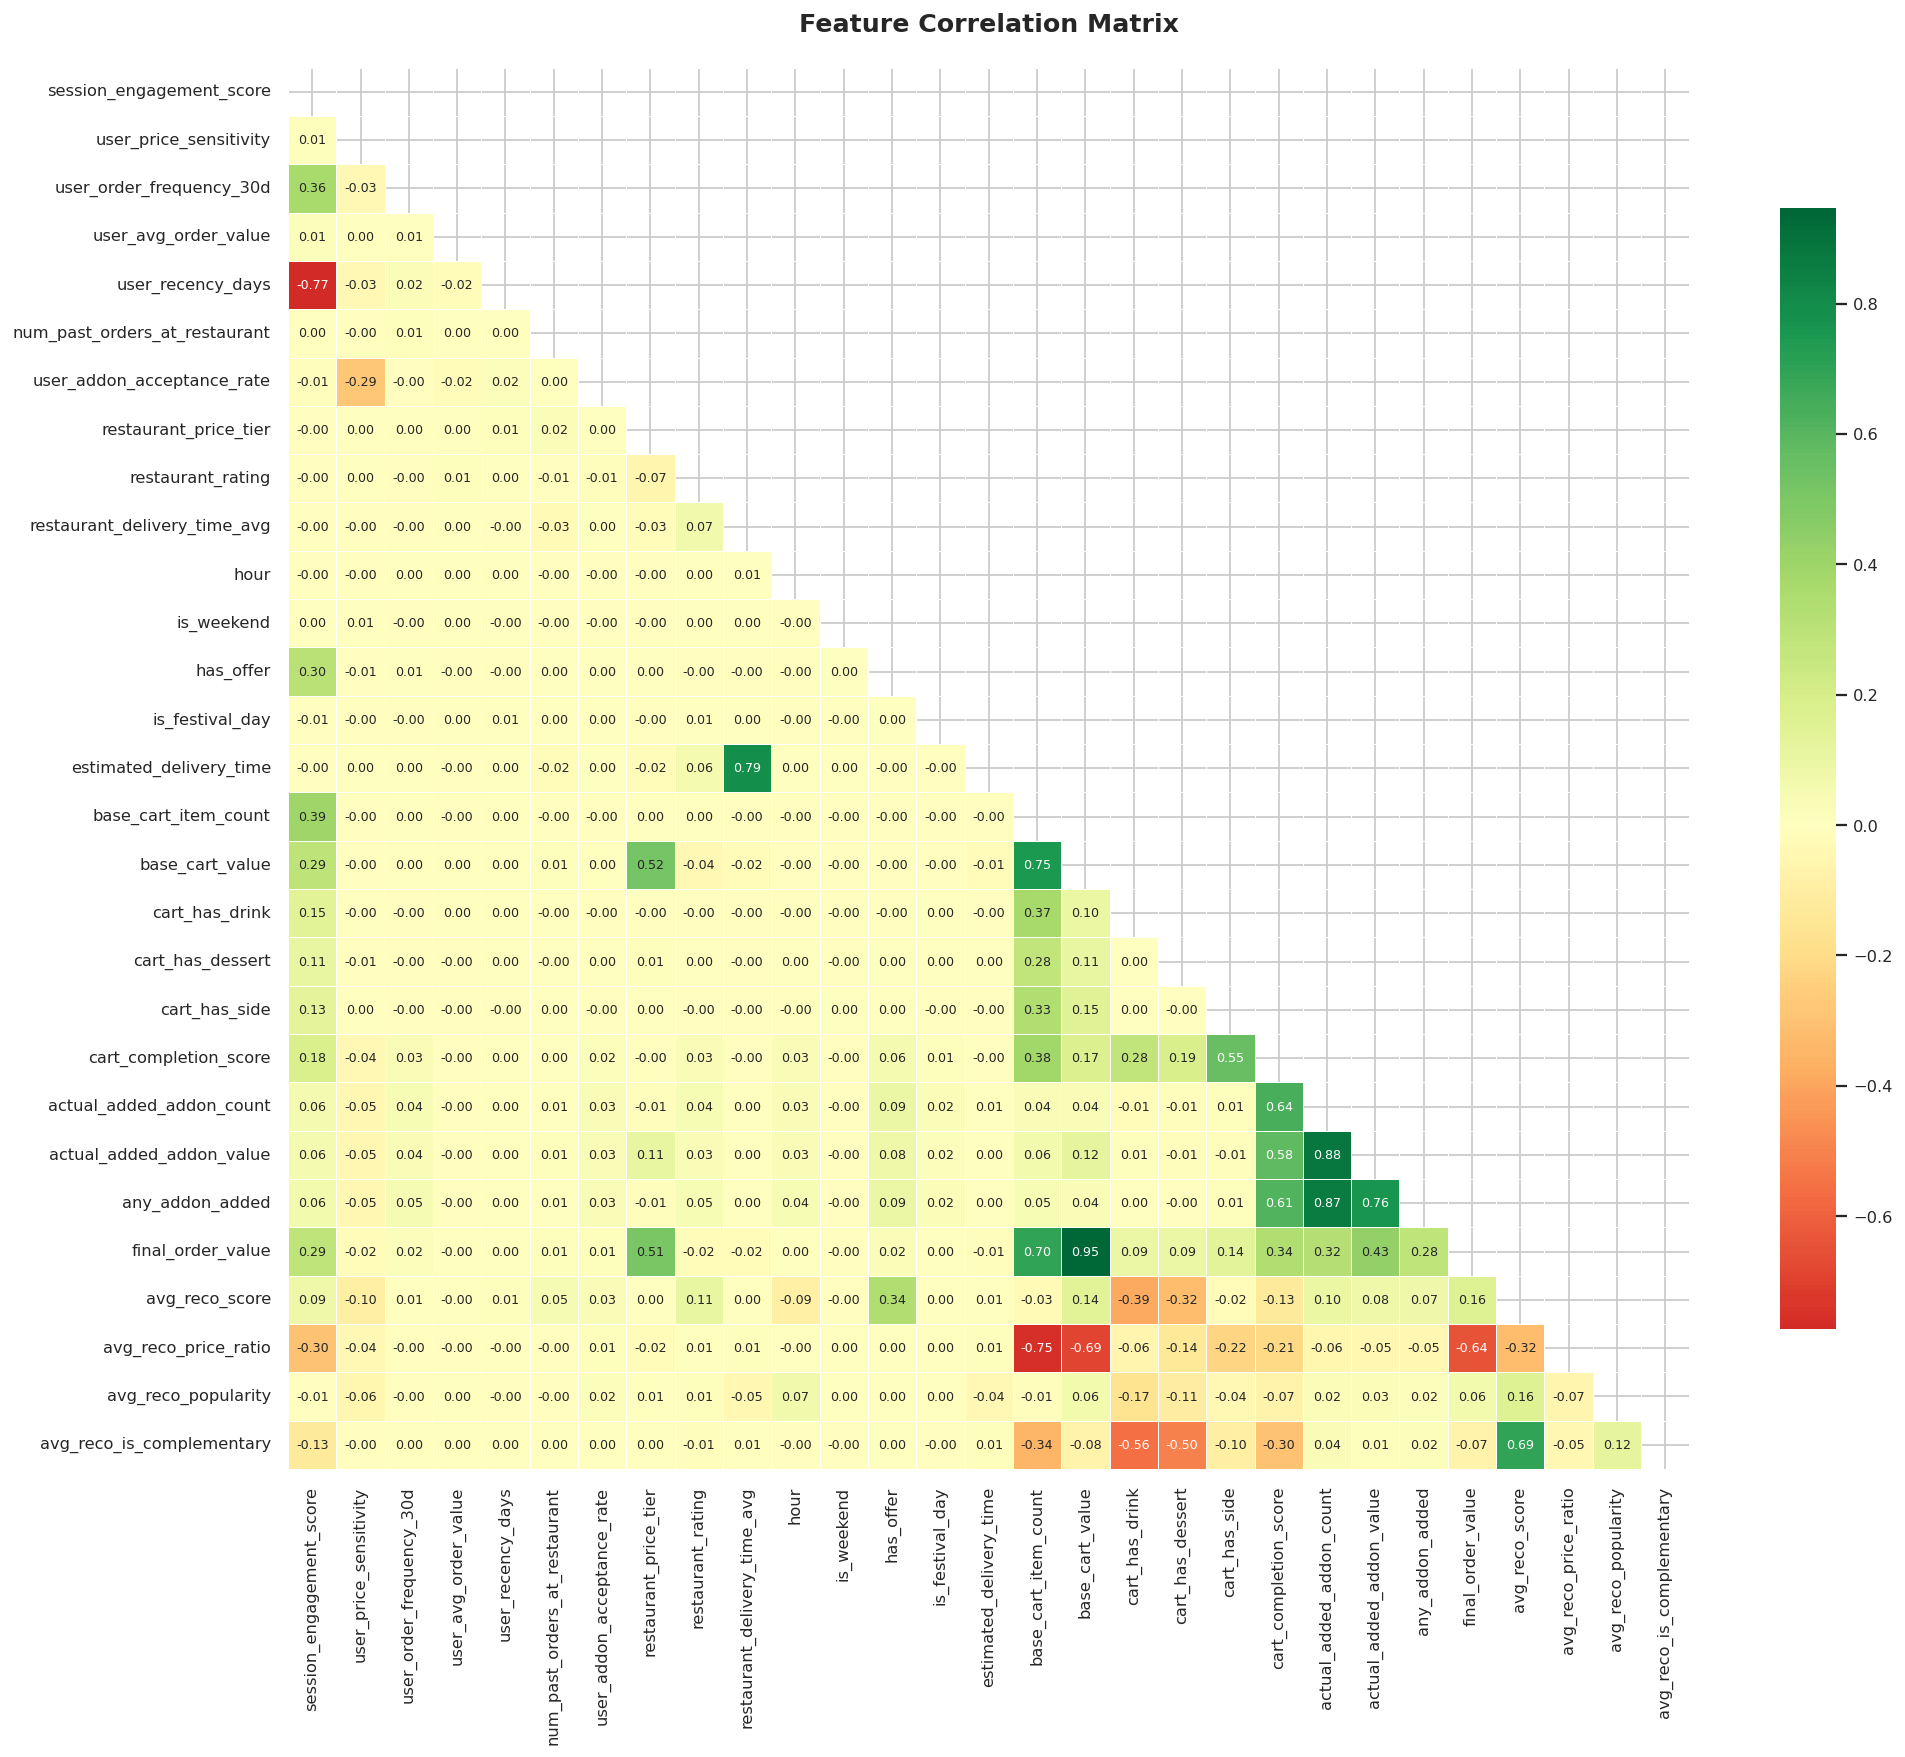

In [57]:
# -------------------------------
# Correlation Matrix Heatmap
# -------------------------------

# List of numeric columns to include in correlation analysis
numeric_cols = [
    'session_engagement_score', 'user_price_sensitivity', 'user_order_frequency_30d',
    'user_avg_order_value', 'user_recency_days', 'num_past_orders_at_restaurant',
    'user_addon_acceptance_rate', 'restaurant_price_tier', 'restaurant_rating',
    'restaurant_delivery_time_avg', 'hour', 'is_weekend', 'has_offer',
    'is_festival_day', 'estimated_delivery_time', 'base_cart_item_count',
    'base_cart_value', 'cart_has_drink', 'cart_has_dessert', 'cart_has_side',
    'cart_completion_score', 'actual_added_addon_count', 'actual_added_addon_value',
    'any_addon_added', 'final_order_value', 'avg_reco_score',
    'avg_reco_price_ratio', 'avg_reco_popularity', 'avg_reco_is_complementary',
]

# Compute correlation matrix
corr = df[numeric_cols].corr()

# Create figure
fig, ax = plt.subplots(figsize=(18, 14))

# Create mask to hide upper triangle of the matrix
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot heatmap
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 7}
)

# Add title
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=20)

# Save the figure
savefig('11_correlation_matrix.png', fig)

This code selects important numeric features, calculates their correlation matrix, and visualizes the relationships using a heatmap. Only one half of the matrix is shown to avoid duplicate information.

In [58]:
# -------------------------------
# Add-on revenue share feature
# -------------------------------

# Calculate add-on value as a fraction of final order value
# Replace 0 in final_order_value with NaN to avoid division by zero
df['addon_revenue_share'] = (
    df['actual_added_addon_value'] /
    df['final_order_value'].replace(0, np.nan)
).fillna(0).round(3)  # Fill invalid results with 0 and round to 3 decimals

This code creates a new feature called addon_revenue_share, which shows what fraction of the final order value came from add-ons. It safely handles cases where the final order value is 0 to avoid division errors.

In [59]:
# -------------------------------
# Add-on rate feature
# -------------------------------

# Calculate add-ons added per base cart item
# Replace 0 in base_cart_item_count with NaN to avoid division by zero
df['add_on_rate'] = (
    df['actual_added_addon_count'] /
    df['base_cart_item_count'].replace(0, np.nan)
).fillna(0).round(3)  # Fill invalid results with 0 and round to 3 decimals

This code creates a new feature add_on_rate, which measures the number of add-ons added per base cart item. It replaces 0 cart item counts with NaN to avoid division by zero, then fills missing values with 0.

In [60]:
# -------------------------------
# Cart value per item feature
# -------------------------------

# Calculate average base cart value per item
# Replace 0 in base_cart_item_count with NaN to avoid division by zero
df['cart_value_per_item'] = (
    df['base_cart_value'] /
    df['base_cart_item_count'].replace(0, np.nan)
).fillna(0).round(2)  # Fill invalid results with 0 and round to 2 decimals

This code creates a new feature cart_value_per_item, which calculates the average value of each item in the base cart. It avoids division by zero by replacing 0 item counts with NaN, then fills missing values with 0.

In [61]:
# -------------------------------
# User loyalty score feature
# -------------------------------

# Create a composite loyalty score using:
# 1. Normalized order frequency
# 2. Inverse of normalized recency
# 3. Normalized past orders at the same restaurant
df['user_loyalty_score'] = (
    df['user_order_frequency_30d'] / df['user_order_frequency_30d'].max()
    - df['user_recency_days'] / df['user_recency_days'].max()
    + df['num_past_orders_at_restaurant'] / df['num_past_orders_at_restaurant'].max()
).round(3)  # Round result to 3 decimals

This code creates a new feature user_loyalty_score, which combines order frequency, recency, and past orders at the same restaurant into a single score. Higher frequency and past restaurant orders increase the score, while higher recency days reduce it.

In [62]:
# -------------------------------
# Recommendation attractiveness feature
# -------------------------------

# Calculate recommendation attractiveness
# Higher recommendation score and popularity increase the value
# Higher price ratio reduces the value
# Add 0.01 in denominator to avoid division by zero
df['reco_attractiveness'] = (
    df['avg_reco_score'] *
    df['avg_reco_popularity'] /
    (df['avg_reco_price_ratio'] + 0.01)
).round(3)  # Round result to 3 decimals

This code creates a new feature reco_attractiveness, which measures how attractive the recommendations are by combining recommendation score and popularity, while reducing the value when the price ratio is high.

In [63]:
# -------------------------------
# Cart diversity flag feature
# -------------------------------

# Check if the cart contains at least 2 out of:
# drink, dessert, and side
df['cart_diversity_flag'] = (
    (df['cart_has_drink'] + df['cart_has_dessert'] + df['cart_has_side']) >= 2
).astype(int)  # Convert True/False to 1/0

This code creates a new binary feature cart_diversity_flag, which checks whether the cart contains at least two among drink, dessert, and side. It assigns 1 if the cart is diverse, otherwise 0.

In [64]:
# -------------------------------
# Add-on upsell flag feature
# -------------------------------

# Mark sessions where addon_revenue_share is above the 75th percentile
df['addon_upsell_flag'] = (
    df['addon_revenue_share'] > df['addon_revenue_share'].quantile(0.75)
).astype(int)  # Convert True/False to 1/0

This code creates a binary feature addon_upsell_flag, which marks sessions where the add-on revenue share is in the top 25%. It assigns 1 to high upsell sessions and 0 otherwise.

In [65]:
# -------------------------------
# High engagement flag feature
# -------------------------------

# Mark sessions where session_engagement_score is above the 75th percentile
df['high_engagement_flag'] = (
    df['session_engagement_score'] > df['session_engagement_score'].quantile(0.75)
).astype(int)  # Convert True/False to 1/0

This code creates a binary feature high_engagement_flag, which marks sessions where the engagement score is in the top 25%. It assigns 1 to highly engaged sessions and 0 to the rest.

In [66]:
# -------------------------------
# List of engineered features
# -------------------------------

# Store names of all newly created features
new_feats = [
    'addon_revenue_share',
    'add_on_rate',
    'cart_value_per_item',
    'user_loyalty_score',
    'reco_attractiveness',
    'cart_diversity_flag',
    'addon_upsell_flag',
    'high_engagement_flag',
]

# Print heading
print("  Engineered features:")

# Print each feature name one by one
for f in new_feats:
    print(f"    → {f}")

  Engineered features:
    → addon_revenue_share
    → add_on_rate
    → cart_value_per_item
    → user_loyalty_score
    → reco_attractiveness
    → cart_diversity_flag
    → addon_upsell_flag
    → high_engagement_flag


This code stores the names of all newly engineered features in a list and then prints them, making it easy to review which new columns were created.

Saved: D:\Data Analytics\Project 2\Output\12_feature_engineering.png


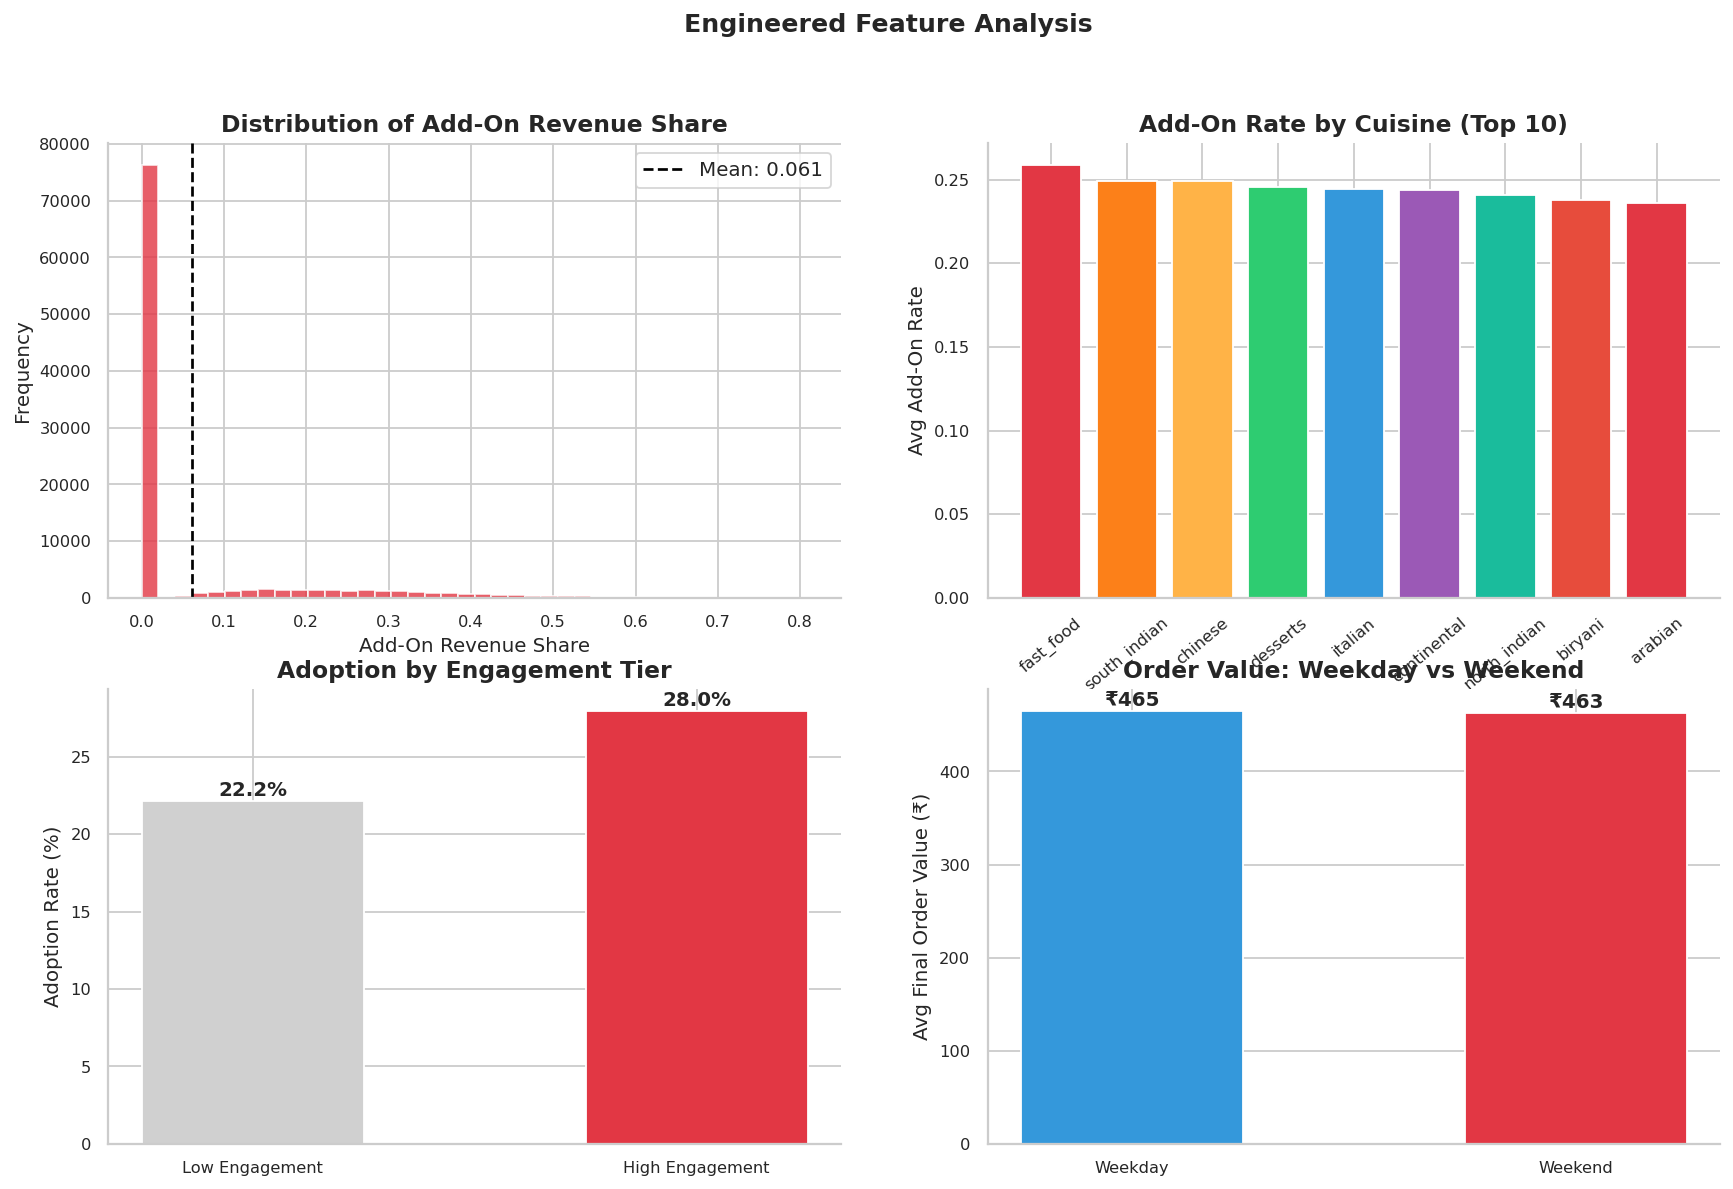

In [67]:
# -------------------------------
# Engineered Feature Analysis
# -------------------------------

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Engineered Feature Analysis', fontsize=14, fontweight='bold')


# -------------------------------
# 1. Distribution of add-on revenue share
# -------------------------------

axes[0, 0].hist(
    df['addon_revenue_share'],
    bins=40,
    color=ZOMATO_RED,
    alpha=0.8,
    edgecolor='white'
)

# Add mean reference line
axes[0, 0].axvline(
    df['addon_revenue_share'].mean(),
    color='black',
    linestyle='--',
    label=f"Mean: {df['addon_revenue_share'].mean():.3f}"
)

axes[0, 0].set_xlabel('Add-On Revenue Share')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Add-On Revenue Share', fontweight='bold')
axes[0, 0].legend()


# -------------------------------
# 2. Add-on rate by cuisine
# -------------------------------

# Get top 10 cuisines with highest average add-on rate
addon_by_cuisine = (
    df.groupby('restaurant_cuisine')['add_on_rate']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

axes[0, 1].bar(
    addon_by_cuisine.index,
    addon_by_cuisine.values,
    color=PALETTE[:len(addon_by_cuisine)],
    edgecolor='white'
)

axes[0, 1].set_xlabel('Cuisine')
axes[0, 1].set_ylabel('Avg Add-On Rate')
axes[0, 1].set_title('Add-On Rate by Cuisine (Top 10)', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=40)


# -------------------------------
# 3. Adoption by engagement tier
# -------------------------------

# Calculate adoption rate for low vs high engagement sessions
reco_adopt = df.groupby('high_engagement_flag')['any_addon_added'].mean() * 100

axes[1, 0].bar(
    ['Low Engagement', 'High Engagement'],
    reco_adopt.values,
    color=['#D0D0D0', ZOMATO_RED],
    edgecolor='white',
    width=0.5
)

axes[1, 0].set_ylabel('Adoption Rate (%)')
axes[1, 0].set_title('Adoption by Engagement Tier', fontweight='bold')

# Add labels above bars
for i, val in enumerate(reco_adopt.values):
    axes[1, 0].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)


# -------------------------------
# 4. Final order value: weekday vs weekend
# -------------------------------

# Calculate average final order value for weekday and weekend
wknd_val = df.groupby('is_weekend')['final_order_value'].mean()

axes[1, 1].bar(
    ['Weekday', 'Weekend'],
    wknd_val.values,
    color=['#3498DB', ZOMATO_RED],
    edgecolor='white',
    width=0.5
)

axes[1, 1].set_ylabel('Avg Final Order Value (₹)')
axes[1, 1].set_title('Order Value: Weekday vs Weekend', fontweight='bold')

# Add value labels above bars
for i, val in enumerate(wknd_val.values):
    axes[1, 1].text(i, val + 5, f'₹{val:.0f}', ha='center', fontweight='bold', fontsize=11)


# -------------------------------
# Save the figure
# -------------------------------

savefig('12_feature_engineering.png', fig)

This code visualizes some of the engineered features using four plots. It shows the distribution of add-on revenue share, compares add-on rate across cuisines, checks adoption by engagement level, and compares final order value between weekdays and weekends.

In [ ]:
# -------------------------------
# K-Means Cluster Optimisation
# -------------------------------

# Select features to use for clustering
cluster_features = [
    'session_engagement_score',
    'base_cart_item_count',
    'actual_added_addon_count',
    'final_order_value',
    'addon_revenue_share',
    'add_on_rate',
    'any_addon_added',
    'is_weekend',
    'user_price_sensitivity',
    'user_addon_acceptance_rate',
    'avg_reco_score',
    'cart_completion_score',
]

# Create clustering dataset and replace missing values with 0
X_cluster = df[cluster_features].fillna(0)

# Standardize features so all variables are on the same scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Lists to store evaluation metrics
inertias = []
sil_scores = []

# Range of k values to test
K_range = range(2, 9)

# Fit K-Means for each k and store inertia + silhouette score
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)

    inertias.append(km.inertia_)  # Elbow metric
    sil_scores.append(silhouette_score(X_scaled, km.labels_))  # Cluster quality metric


# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('K-Means Cluster Optimisation', fontsize=14, fontweight='bold')


# -------------------------------
# 1. Elbow curve
# -------------------------------

axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(4, color=ZOMATO_RED, linestyle='--', label='Selected k=4')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Curve', fontweight='bold')
axes[0].legend()


# -------------------------------
# 2. Silhouette score plot
# -------------------------------

axes[1].plot(list(K_range), sil_scores, 'rs-', linewidth=2, markersize=8)
axes[1].axvline(4, color=ZOMATO_RED, linestyle='--', label='Selected k=4')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k', fontweight='bold')
axes[1].legend()


# Save the figure
savefig('13_cluster_optimisation.png', fig)

This code prepares selected features for K-Means clustering, scales them, and evaluates different values of k using the elbow method and silhouette score. It then plots both metrics to help choose the optimal number of clusters.

In [ ]:
# -------------------------------
# Fit final K-Means model and profile clusters
# -------------------------------

# Set chosen number of clusters
OPTIMAL_K = 4

# Initialize K-Means model
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)

# Fit model and assign cluster labels to each row
df['cluster'] = kmeans.fit_predict(X_scaled)

# Print confirmation and clustering quality
print(f"  K-Means fitted with k={OPTIMAL_K}")
print(f"  Silhouette Score: {silhouette_score(X_scaled, df['cluster']):.4f}")

# Create average profile of each cluster
cluster_profile = df.groupby('cluster')[cluster_features + ['final_order_value']].mean().round(2)

# Print cluster profiles
print("\n── Cluster Profiles ────────────────────────────────────────")
print(cluster_profile.to_string())

This code fits the K-Means model using the selected number of clusters, assigns each session to a cluster, prints the silhouette score, and then creates a cluster profile by calculating the average values of important features for each cluster.

In [ ]:
|